# Protein Substrates of Memory in Stentor coeruleus 

## Notebook Setup

In [1]:
#Notebook Setup

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as SS
from statsmodels.stats.multitest import fdrcorrection
from matplotlib import rc
from scipy import stats
from scipy.stats import zscore

import os
import pickle as pkl

rc('text', usetex=False)
rc('text.latex', preamble=r'\usepackage{cmbright}')
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})

%matplotlib inline

# This enables SVG graphics inline. 
%config InlineBackend.figure_formats = {'png', 'retina'}

rc = {'lines.linewidth': 2,
      'axes.labelsize': 18, 
      'axes.titlesize': 18, 
      'axes.facecolor': 'DFDFE5'}
sns.set_context('notebook', rc=rc)
sns.set_style("dark")

mpl.rcParams['xtick.labelsize'] = 16 
mpl.rcParams['ytick.labelsize'] = 16 
mpl.rcParams['legend.fontsize'] = 14

In [2]:
# for calculating qvalue 
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri

# Enable conversion between R and numpy
numpy2ri.activate()

# Load the R `qvalue` package
ro.r('library(qvalue)')

def compute_qvalues_r(pvals):
    """
    calculate q-values with R qvalue package
    """
    pvals = np.array(pvals)

    pvals_r = ro.FloatVector(pvals)  # Convert to R vector
    qvalue_func = ro.r('function(p) qvalue(p, robust=TRUE)$qvalues') 
    qvals = np.array(qvalue_func(pvals_r))  # Convert back to NumPy array

    return qvals

# example
#qvals = compute_qvalues_r(pvals)

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: package ‘qvalue’ was built under R version 4.4.2 



In [3]:
# load color dictionary 

filename = "learnsample_color_dict.pkl"

with open(filename, "rb") as file:
    color_dict = pkl.load(file)

In [4]:
color_dict

{'t_0': '#4477AA',
 'ut_19': '#EE6677',
 't_19': '#228833',
 'f_10': '#CCBB44',
 'ut_f_10': '#66CCEE',
 'f_90': '#AA3377',
 'ut_f_90': '#BBBBBB'}

In [5]:
# label dictionary for legends in figures 

label_dict = {
    't_0':'time 0',
    'ut_19':'19 hrs no training', 
    't_19':'19 hrs training',
    'f_10':'19 hrs training + 10 min forgetting',
    'f_90': '19 hrs training + 90 min forgetting', 
    'ut_f_10':'19 hrs + 10 min no training', 
    'ut_f_90':'19 hours + 90 min no training'
}


## Load data

proteomics dataframe:

In [6]:
df = pd.read_csv('/Volumes/albright_postdoc/deepa/exp2/Stentor_Learning_Global_DIA_Protein_log2.csv')

In [7]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [8]:
df.rename(columns={'T: PG.ProteinGroups': 'prot_group', 'T: PG.Genes': 'gene'}, inplace=True)

In [9]:
df

,prot_group,gene,T: PG.Organisms,T: PG.ProteinDescriptions,[1] Stentor_Control_19h_10m_4C_11_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[2] Stentor_Control_19h_10m_5C_13_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[3] Stentor_Control_19h_10m_6C_15_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[4] Stentor_Control_19h_1C_03_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[5] Stentor_Control_19h_2C_06_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[6] Stentor_Control_19h_3C_09_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,...,[12] Stentor_Control_3B_08_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[13] Stentor_Train_19h_1A_01_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[14] Stentor_Train_19h_2A_04_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[15] Stentor_Train_19h_3A_07_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[16] Stentor_Train_19h_Forget_10m_4A_10_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[17] Stentor_Train_19h_Forget_10m_5A_12_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[18] Stentor_Train_19h_Forget_10m_6A_14_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[19] Stentor_Train_19h_Forget_90m_7A_16_FAIMS_DIA_Lisa15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[20] Stentor_Train_19h_Forget_90m_8A_18_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[21] Stentor_Train_19h_Forget_90m_9A_20_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity
0,A0A060BG28,BTU06,Stentor coeruleus,Tubulin beta chain,25.8206,25.5858,27.1740,25.8792,25.6972,25.6501,...,25.3832,25.8099,25.6614,25.5919,26.7726,25.9573,25.7557,25.7337,26.9378,25.7863
1,A0A060BG32,RdRP05,Stentor coeruleus,RNA-dependent RNA polymerase,16.9754,17.1098,17.6967,16.8884,16.7755,16.4875,...,16.6420,16.9370,17.0430,16.9237,16.9578,16.8431,16.8052,16.7436,16.3761,16.8735
2,A0A060BJF3,RdRP01,Stentor coeruleus,RNA-dependent RNA polymerase,16.6124,16.6892,16.4266,16.5382,16.1426,16.6818,...,16.5035,16.4984,16.6969,16.6578,16.7422,16.8247,16.7774,16.4453,16.8253,16.5597
3,A0A060BJG0,ATU07,Stentor coeruleus,Tubulin alpha chain,19.1014,18.4691,20.7402,18.8555,18.5120,19.1355,...,19.1221,19.4709,19.3378,19.2689,19.8235,19.0254,18.5879,18.6513,19.9358,19.3279
4,A0A060BJH0,Sciwi14,Stentor coeruleus,Piwi-like protein 14,16.1812,15.9531,14.9872,16.1016,15.9152,16.0804,...,15.8428,15.8951,16.0664,15.9176,16.5919,16.3013,16.2422,16.4294,15.0681,16.0809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9545,A0A1R2D563,SteCoe_107,Stentor coeruleus,Thioredoxin domain-containing protein,16.9958,16.5066,14.5680,15.9584,16.7462,16.5290,...,16.4202,16.4039,16.7524,16.2657,15.9212,16.9537,15.8053,16.1961,16.4737,16.5216
9546,A0A1R2D575,SteCoe_110,Stentor coeruleus,Aldehyde dehydrogenase domain-containing protein,17.7654,17.6400,17.0211,17.7174,17.6594,17.4489,...,17.8830,17.3413,18.0274,16.7209,17.8950,18.0445,17.5747,17.9261,17.1719,16.6513
9547,A0A1R2D582,SteCoe_136,Stentor coeruleus,Uncharacterized protein,14.5290,14.5276,14.4249,14.1376,14.1685,14.4381,...,14.4107,14.2459,14.5274,14.3162,14.4360,14.5039,14.3289,14.6481,14.9903,14.6546
9548,A0A1R2D586,SteCoe_100,Stentor coeruleus,PH domain-containing protein,12.7521,12.2354,16.1394,11.8216,12.6478,12.1823,...,12.7805,12.9500,13.0035,12.4113,12.5936,12.8199,12.7096,12.5267,14.0748,12.8562


In [10]:
df.drop(df.columns[[0, 2, 3]], axis=1, inplace=True)

In [11]:
df

,gene,[1] Stentor_Control_19h_10m_4C_11_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[2] Stentor_Control_19h_10m_5C_13_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[3] Stentor_Control_19h_10m_6C_15_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[4] Stentor_Control_19h_1C_03_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[5] Stentor_Control_19h_2C_06_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[6] Stentor_Control_19h_3C_09_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[7] Stentor_Control_19h_90m_7C_17_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[8] Stentor_Control_19h_90m_8C_19_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[9] Stentor_Control_19h_90m_9C_21_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,...,[12] Stentor_Control_3B_08_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[13] Stentor_Train_19h_1A_01_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[14] Stentor_Train_19h_2A_04_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[15] Stentor_Train_19h_3A_07_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[16] Stentor_Train_19h_Forget_10m_4A_10_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[17] Stentor_Train_19h_Forget_10m_5A_12_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[18] Stentor_Train_19h_Forget_10m_6A_14_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[19] Stentor_Train_19h_Forget_90m_7A_16_FAIMS_DIA_Lisa15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[20] Stentor_Train_19h_Forget_90m_8A_18_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[21] Stentor_Train_19h_Forget_90m_9A_20_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity
0,BTU06,25.8206,25.5858,27.1740,25.8792,25.6972,25.6501,25.8450,25.9153,25.8117,...,25.3832,25.8099,25.6614,25.5919,26.7726,25.9573,25.7557,25.7337,26.9378,25.7863
1,RdRP05,16.9754,17.1098,17.6967,16.8884,16.7755,16.4875,17.1331,19.0829,16.8279,...,16.6420,16.9370,17.0430,16.9237,16.9578,16.8431,16.8052,16.7436,16.3761,16.8735
2,RdRP01,16.6124,16.6892,16.4266,16.5382,16.1426,16.6818,16.7229,16.5642,16.7597,...,16.5035,16.4984,16.6969,16.6578,16.7422,16.8247,16.7774,16.4453,16.8253,16.5597
3,ATU07,19.1014,18.4691,20.7402,18.8555,18.5120,19.1355,18.7482,19.2776,18.7596,...,19.1221,19.4709,19.3378,19.2689,19.8235,19.0254,18.5879,18.6513,19.9358,19.3279
4,Sciwi14,16.1812,15.9531,14.9872,16.1016,15.9152,16.0804,16.1691,15.3747,16.2261,...,15.8428,15.8951,16.0664,15.9176,16.5919,16.3013,16.2422,16.4294,15.0681,16.0809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9545,SteCoe_107,16.9958,16.5066,14.5680,15.9584,16.7462,16.5290,16.4101,16.1899,16.6356,...,16.4202,16.4039,16.7524,16.2657,15.9212,16.9537,15.8053,16.1961,16.4737,16.5216
9546,SteCoe_110,17.7654,17.6400,17.0211,17.7174,17.6594,17.4489,17.9672,17.5812,17.7721,...,17.8830,17.3413,18.0274,16.7209,17.8950,18.0445,17.5747,17.9261,17.1719,16.6513
9547,SteCoe_136,14.5290,14.5276,14.4249,14.1376,14.1685,14.4381,14.5656,13.7238,14.7822,...,14.4107,14.2459,14.5274,14.3162,14.4360,14.5039,14.3289,14.6481,14.9903,14.6546
9548,SteCoe_100,12.7521,12.2354,16.1394,11.8216,12.6478,12.1823,12.9310,12.4753,12.4857,...,12.7805,12.9500,13.0035,12.4113,12.5936,12.8199,12.7096,12.5267,14.0748,12.8562


In [12]:
df.set_index('gene', inplace=True)


samples to conditions table:

In [13]:
s2c = pd.read_csv('/Volumes/albright_postdoc/deepa/exp2/bin/proteomics_sample_map.csv', header=None)

In [14]:
s2c = s2c.T

In [15]:
s2c.columns = s2c.iloc[0]

In [16]:
s2c = s2c.drop(0)

In [17]:
s2c = s2c.rename({'proteomics_ID': 'sample', 'sample': 'condition'})

In [18]:
new_col = ['sample', 'condition', 'batch']

In [19]:
s2c.columns = new_col

In [20]:
s2c.set_index('sample', inplace=True)

In [21]:
s2c

,condition,batch
sample,,
[1] Stentor_Control_19h_10m_4C_11_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_f_10,4
[2] Stentor_Control_19h_10m_5C_13_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_f_10,5
[3] Stentor_Control_19h_10m_6C_15_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_f_10,6
[4] Stentor_Control_19h_1C_03_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_19,1
[5] Stentor_Control_19h_2C_06_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_19,2
[6] Stentor_Control_19h_3C_09_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_19,3
[7] Stentor_Control_19h_90m_7C_17_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_f_90,7
[8] Stentor_Control_19h_90m_8C_19_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_f_90,8
[9] Stentor_Control_19h_90m_9C_21_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_f_90,9


We decided to remove the following controls from the RNA-seq experiment (see XXXX notebook), so we're removing them here as well. 

In [22]:
# remove redundant control groups
samples_to_remove = s2c.index[s2c["condition"].isin(["ut_f_10", "ut_f_90"])]
df = df.drop(columns=samples_to_remove)

s2c = s2c.drop(index=samples_to_remove)

## Data Prep and PCA

                                                          PC1        PC2
[4] Stentor_Control_19h_1C_03_FAIMS_DIA_Lisa_15...  21.345857  23.108828
[5] Stentor_Control_19h_2C_06_FAIMS_DIA_Lisa_15... -12.600677 -52.046412
[6] Stentor_Control_19h_3C_09_FAIMS_DIA_Lisa_09...   6.665680 -32.446629
[10] Stentor_Control_1B_02_FAIMS_DIA_Lisa_15Sep...  11.434947 -25.662467
[11] Stentor_Control_2B_05_FAIMS_DIA_Lisa_09Sep...  25.821358  42.098806


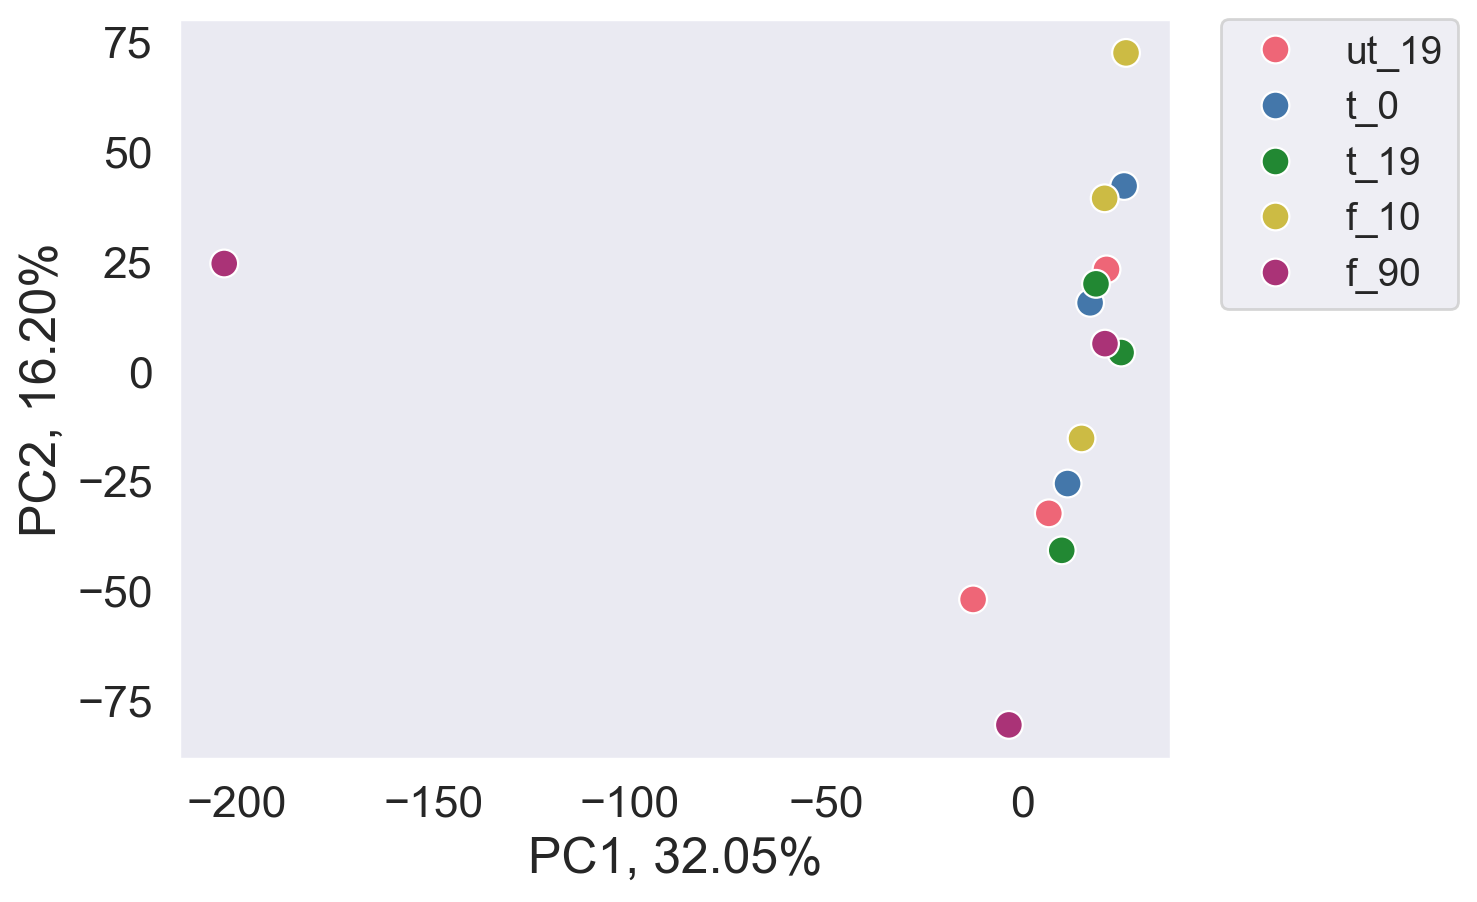

In [23]:
# Standardize the data: mean = 0, std = 1
scaler = SS()
scaled_data = scaler.fit_transform(df.T)

# Perform PCA to reduce to 2 components
pca = PCA(n_components=2)
coords = pca.fit_transform(scaled_data)

# Create DataFrame with PCA results
pc = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=df.T.index)

# Print to check PCA results
print(pc.head())

pc = pd.merge(pc, s2c, left_index=True, right_index=True)

explained_variance = pca.explained_variance_ratio_ * 100  # convert to percentage
# Add variance explained to axis labels
plt.xlabel(f'PC1, {explained_variance[0]:.2f}%')
plt.ylabel(f'PC2, {explained_variance[1]:.2f}%')

# Plot PCA results
sns.scatterplot(x='PC1', y='PC2', hue='condition', palette =color_dict,
                s=100, data=pc)

# Customize legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

# Customize ticks (optional)
# plt.xticks([-50, 0, 50, 100])
# plt.yticks([-50, 0, 50, 100])

# Save the plot
#plt.savefig('PCA_conditions.png', bbox_inches='tight', dpi=300)

plt.show()

In [24]:
pc

,PC1,PC2,condition,batch
[4] Stentor_Control_19h_1C_03_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,21.345857,23.108828,ut_19,1
[5] Stentor_Control_19h_2C_06_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,-12.600677,-52.046412,ut_19,2
[6] Stentor_Control_19h_3C_09_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,6.665680,-32.446629,ut_19,3
[10] Stentor_Control_1B_02_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,11.434947,-25.662467,t_0,1
[11] Stentor_Control_2B_05_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,25.821358,42.098806,t_0,2
[12] Stentor_Control_3B_08_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,17.169531,15.494075,t_0,3
[13] Stentor_Train_19h_1A_01_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,18.669138,19.815707,t_19,1
[14] Stentor_Train_19h_2A_04_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,25.058449,4.169922,t_19,2
[15] Stentor_Train_19h_3A_07_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,9.956176,-40.870410,t_19,3
[16] Stentor_Train_19h_Forget_10m_4A_10_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,26.312427,72.409445,f_10,4


Note: Sample[20] appears to be an extreme outlier, will remove. 

In [25]:
s2c.drop(['[20] Stentor_Train_19h_Forget_90m_8A_18_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity'], axis=0, inplace=True)

df.drop(['[20] Stentor_Train_19h_Forget_90m_8A_18_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity'], axis=1, inplace=True)

In [26]:
# also remove from color_dict and label_dict
color_dict = {k: v for k, v in color_dict.items() if k in s2c['condition'].unique()}

                                                          PC1        PC2
[4] Stentor_Control_19h_1C_03_FAIMS_DIA_Lisa_15...  28.552871   6.515634
[5] Stentor_Control_19h_2C_06_FAIMS_DIA_Lisa_15... -67.736699  78.341298
[6] Stentor_Control_19h_3C_09_FAIMS_DIA_Lisa_09... -36.968456  -4.114925
[10] Stentor_Control_1B_02_FAIMS_DIA_Lisa_15Sep... -26.508403  24.122613
[11] Stentor_Control_2B_05_FAIMS_DIA_Lisa_09Sep...  50.889678   2.326358


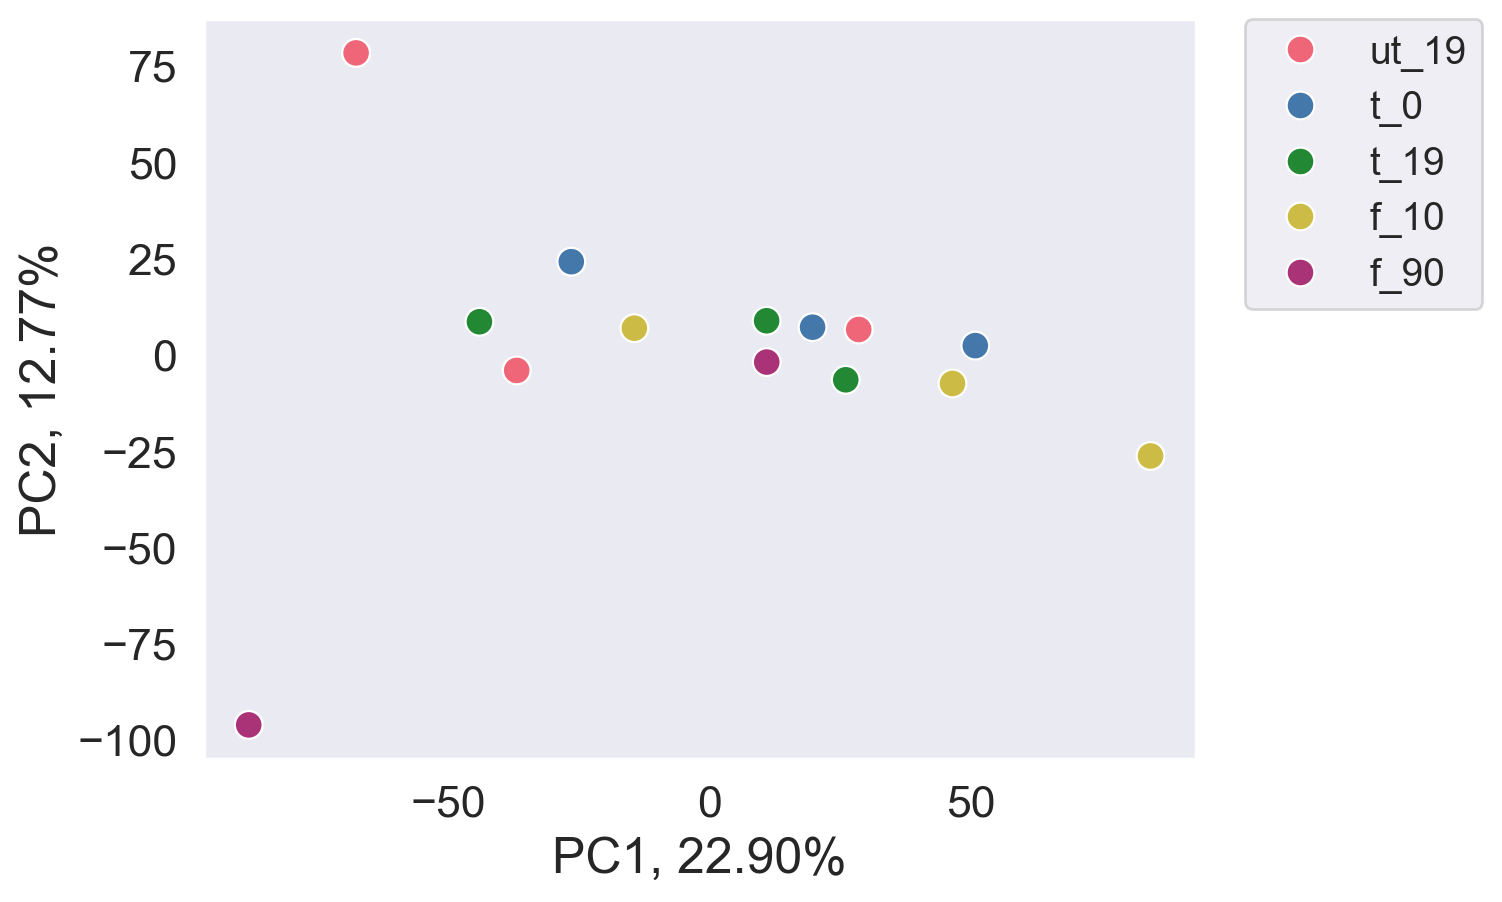

In [27]:
# Standardize the data: mean = 0, std = 1
scaler = SS()
scaled_data = scaler.fit_transform(df.T)

# Perform PCA to reduce to 2 components
pca = PCA(n_components=2)
coords = pca.fit_transform(scaled_data)

# Create DataFrame with PCA results
pc = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=df.T.index)

# Print to check PCA results
print(pc.head())

pc = pd.merge(pc, s2c, left_index=True, right_index=True)

explained_variance = pca.explained_variance_ratio_ * 100  # convert to percentage
# add variance explained to axis labels
plt.xlabel(f'PC1, {explained_variance[0]:.2f}%')
plt.ylabel(f'PC2, {explained_variance[1]:.2f}%')

# plot
sns.scatterplot(x='PC1', y='PC2', hue='condition', palette = color_dict,
                s=100, data=pc)

# Customize legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

# Customize ticks (optional)
# plt.xticks([-50, 0, 50, 100])
# plt.yticks([-50, 0, 50, 100])

# Save the plot
#plt.savefig('PCA_conditions.png', bbox_inches='tight', dpi=300)

plt.show()

Perhaps the two points on the very left are outliers on PC2; however, their 'outlierness' is less extreme than the above. In addition, removing the burgundy f_90 point would leave only 1 replicate. 

## ANOVA + Heatmaps

In [28]:
# df has sample names as columns, make sure s2c index matches the column names in df
if not np.all(df.columns == s2c.index):
    print("Warning: Sample names in df columns and s2c index do not match!")

anova_results = []

# make sure s2c is a Series, otherwise select the appropriate column for the condition
conditions = s2c if isinstance(s2c, pd.Series) else s2c['condition']

# ANOVA for each gene
for gene in df.index:  # iterate over gene rows, since df was transposed earlier
    condition_groups = [df.loc[gene, conditions[conditions == condition].index] for condition in conditions.unique()]
    
    # ANOVA for each gene
    f_stat, p_value = stats.f_oneway(*condition_groups)
    
    # add results
    anova_results.append((gene, f_stat, p_value))

# dataframe
anova_df = pd.DataFrame(anova_results, columns=["Gene", "F-statistic", "p-value"])

In [29]:
anova_df['qval'] = compute_qvalues_r(anova_df['p-value'])

In [30]:
anova_df.sort_values('qval').head(50)

,Gene,F-statistic,p-value,qval
8962,SteCoe_2416,59.455850,0.000002,0.011098
5589,SteCoe_16300,49.545485,0.000004,0.012128
996,SteCoe_34158,45.012906,0.000006,0.012166
1279,SteCoe_33017,41.498223,0.000008,0.012877
5148,SteCoe_18047,33.617355,0.000020,0.024938
1386,SteCoe_32543,28.847483,0.000038,0.039169
2867,SteCoe_26873;SteCoe_9048,24.529293,0.000074,0.048929
3344,SteCoe_25128,23.705979,0.000085,0.048929
4465,SteCoe_20773,24.126444,0.000079,0.048929
2813,SteCoe_27022,23.542843,0.000087,0.048929


In [31]:
top_50_genes = anova_df.sort_values('qval').head(50)

In [32]:
top_50_genes

,Gene,F-statistic,p-value,qval
8962,SteCoe_2416,59.455850,0.000002,0.011098
5589,SteCoe_16300,49.545485,0.000004,0.012128
996,SteCoe_34158,45.012906,0.000006,0.012166
1279,SteCoe_33017,41.498223,0.000008,0.012877
5148,SteCoe_18047,33.617355,0.000020,0.024938
1386,SteCoe_32543,28.847483,0.000038,0.039169
2867,SteCoe_26873;SteCoe_9048,24.529293,0.000074,0.048929
3344,SteCoe_25128,23.705979,0.000085,0.048929
4465,SteCoe_20773,24.126444,0.000079,0.048929
2813,SteCoe_27022,23.542843,0.000087,0.048929


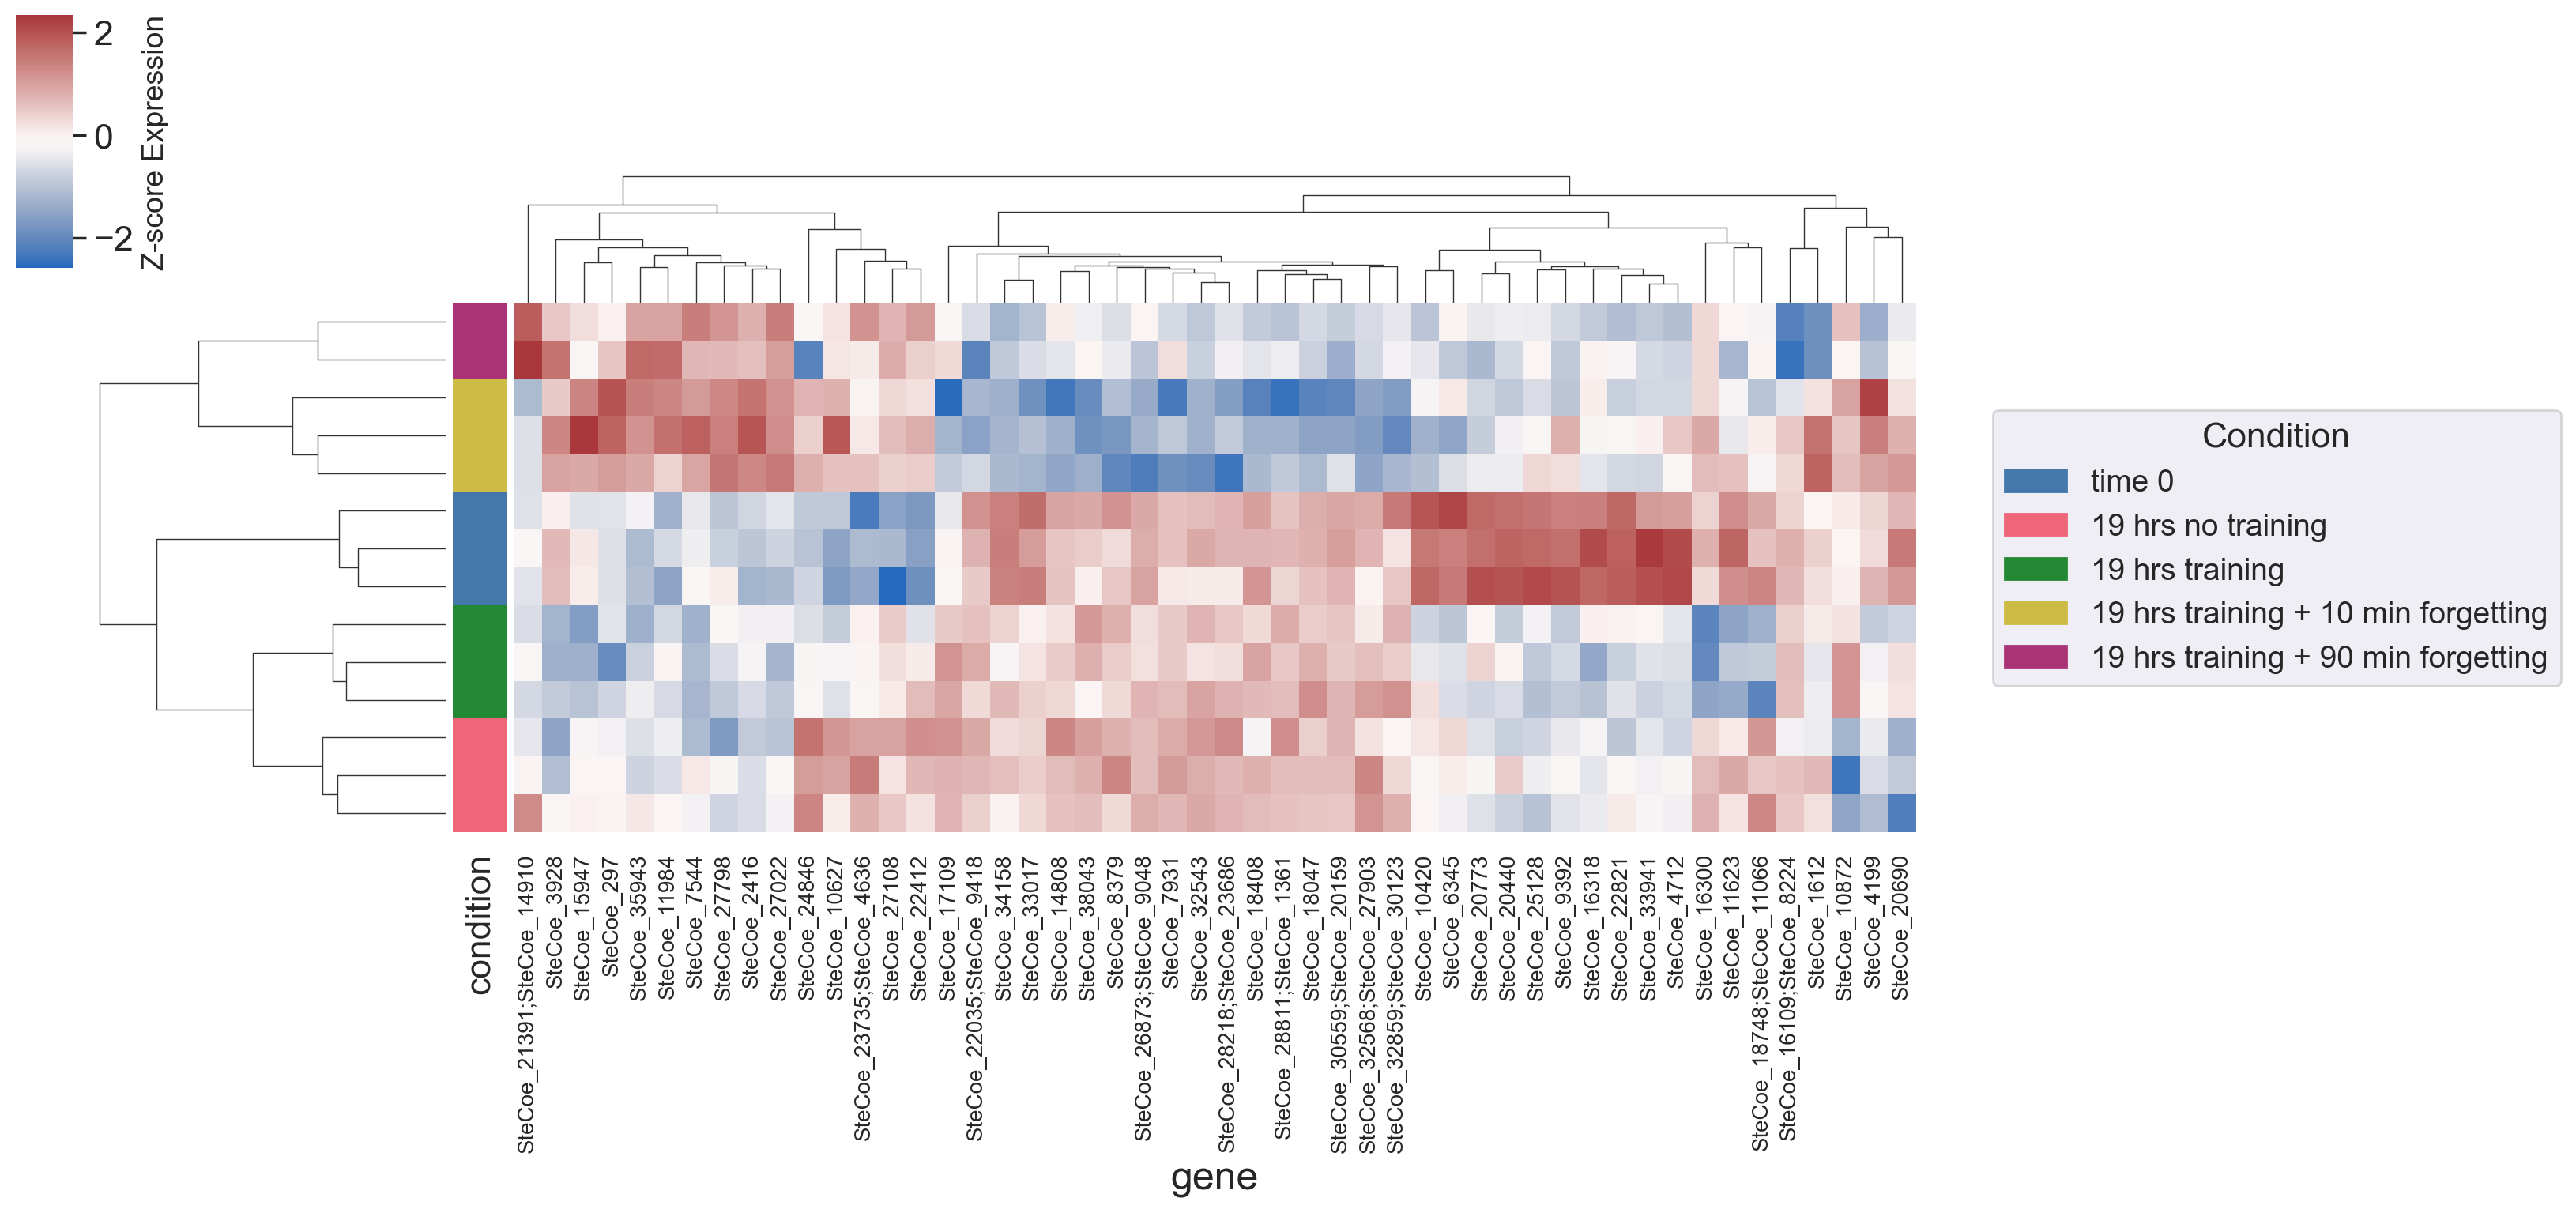

In [33]:
# get expression data for desired genes 
top_50_gene_names = top_50_genes[top_50_genes.qval < 0.3]['Gene']
top_50_expr = df.loc[top_50_gene_names]

# z-score normalize 
top_50_expr_zscore = top_50_expr.apply(zscore, axis=1)

# map sample to the color 
row_colors = s2c['condition'].map(color_dict)

# clustered heatmap by condition 
g = sns.clustermap(
    top_50_expr_zscore.T,  # Transpose to have samples as rows
    cmap="vlag",  # Color map for the heatmap
    annot=False,  # Disable annotations (set to True if needed)
    figsize=(12, 8),  # Size of the plot
    row_colors=row_colors,  # Color the rows based on conditions
    xticklabels = True, 
    yticklabels = False, 
    cbar_pos=(-0.02, 0.9, 0.03, 0.2), 
)

# colorbar label
g.cax.set_ylabel("Z-score Expression", fontsize=13.5, rotation=90)

# condition legend and position relative to z-score colorbar
handles = [mpatches.Patch(color=color_dict[key], label=label_dict[key]) for key in color_dict]
plt.legend(handles=handles, title="Condition", bbox_to_anchor=(45, -0.5), loc='upper right', fontsize = 14, title_fontsize = 16)

# x-axis/gene name settings 
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=10)  # Adjust fontsize as needed
plt.xticks([], rotation=0)

# Save the heatmap
plt.savefig("exp2_prot_hm_ex_zscore.png", bbox_inches="tight", dpi=300)

# Show the plot
plt.show()


## ANOVA + Heatmaps without t_0 

### remove t_0

In [34]:
samples_to_remove = s2c.index[s2c["condition"].isin(["t_0"])]
df_no0 = df.drop(columns=samples_to_remove)

s2c_no0 = s2c.drop(index=samples_to_remove)

In [35]:
s2c_no0

,condition,batch
sample,,
[4] Stentor_Control_19h_1C_03_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_19,1
[5] Stentor_Control_19h_2C_06_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_19,2
[6] Stentor_Control_19h_3C_09_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_19,3
[13] Stentor_Train_19h_1A_01_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,t_19,1
[14] Stentor_Train_19h_2A_04_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,t_19,2
[15] Stentor_Train_19h_3A_07_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,t_19,3
[16] Stentor_Train_19h_Forget_10m_4A_10_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,f_10,4
[17] Stentor_Train_19h_Forget_10m_5A_12_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,f_10,5
[18] Stentor_Train_19h_Forget_10m_6A_14_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,f_10,6


In [36]:
# also remove from color_dict
color_dict_no0 = {k: v for k, v in color_dict.items() if k in s2c_no0['condition'].unique()}

                                                          PC1        PC2
[4] Stentor_Control_19h_1C_03_FAIMS_DIA_Lisa_15...  34.258519  -6.499971
[5] Stentor_Control_19h_2C_06_FAIMS_DIA_Lisa_15... -64.489310 -85.531971
[6] Stentor_Control_19h_3C_09_FAIMS_DIA_Lisa_09... -34.282468   7.741270
[13] Stentor_Train_19h_1A_01_FAIMS_DIA_Lisa_09S...  32.706254   5.569055
[14] Stentor_Train_19h_2A_04_FAIMS_DIA_Lisa_09S...  12.599295 -14.401699


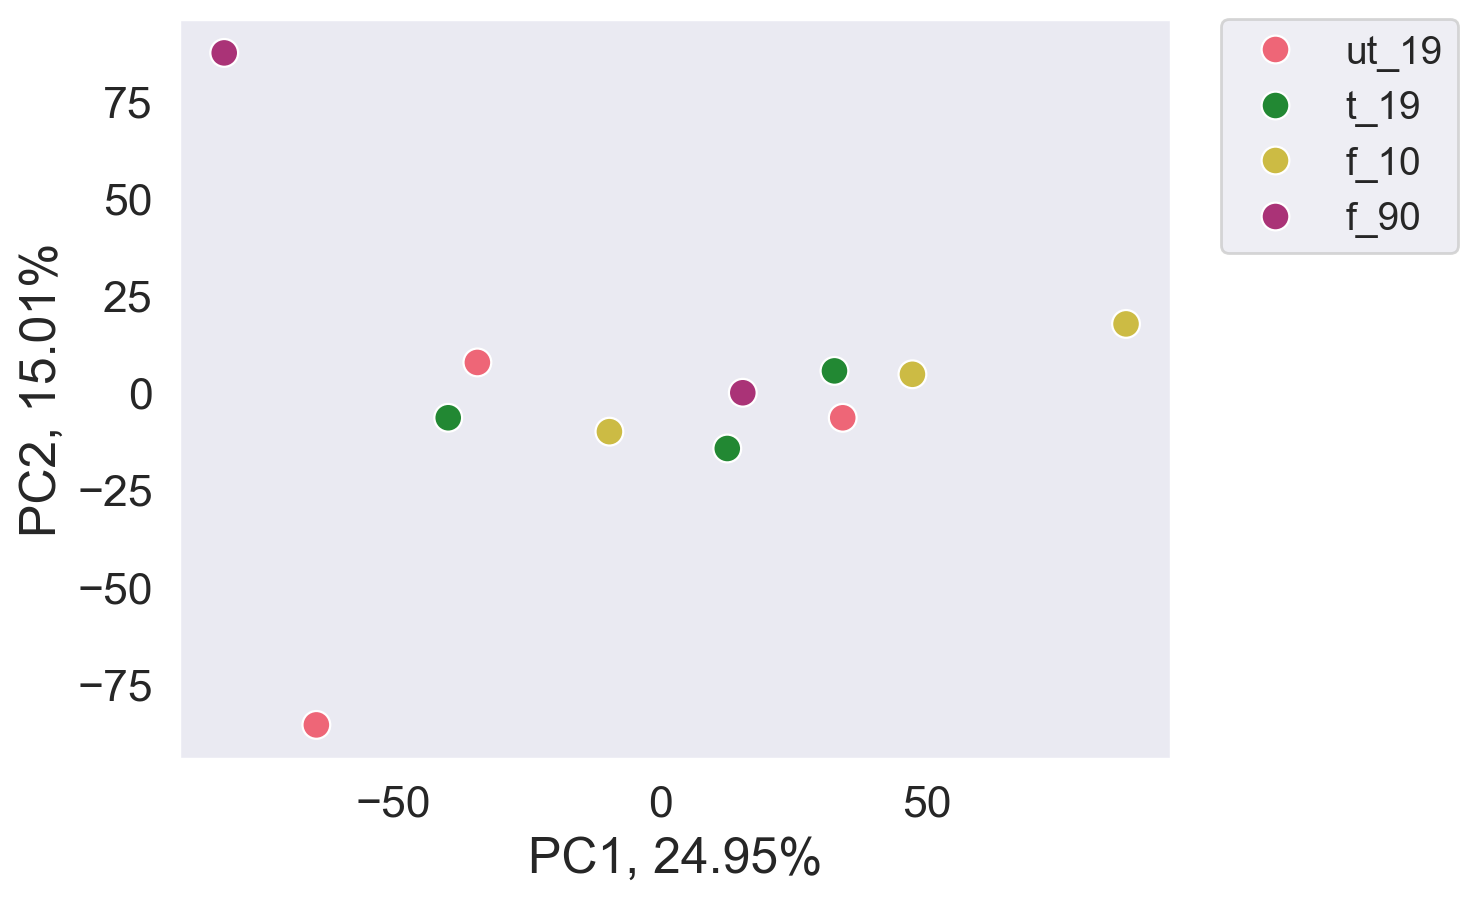

In [37]:
# Standardize the data: mean = 0, std = 1
scaler = SS()
scaled_data = scaler.fit_transform(df_no0.T)

# Perform PCA to reduce to 2 components
pca = PCA(n_components=2)
coords = pca.fit_transform(scaled_data)

# Create DataFrame with PCA results
pc = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=df_no0.T.index)

# Print to check PCA results
print(pc.head())

pc = pd.merge(pc, s2c_no0, left_index=True, right_index=True)

explained_variance = pca.explained_variance_ratio_ * 100  # convert to percentage
# Add variance explained to axis labels
plt.xlabel(f'PC1, {explained_variance[0]:.2f}%')
plt.ylabel(f'PC2, {explained_variance[1]:.2f}%')

# Plot PCA results
sns.scatterplot(x='PC1', y='PC2', hue='condition', palette = color_dict_no0,
                s=100, data=pc)

# Customize legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

# Customize ticks (optional)
# plt.xticks([-50, 0, 50, 100])
# plt.yticks([-50, 0, 50, 100])

# Save the plot
#plt.savefig('PCA_conditions.png', bbox_inches='tight', dpi=300)

plt.show()

In [38]:
pc

,PC1,PC2,condition,batch
[4] Stentor_Control_19h_1C_03_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,34.258519,-6.499971,ut_19,1
[5] Stentor_Control_19h_2C_06_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,-64.489310,-85.531971,ut_19,2
[6] Stentor_Control_19h_3C_09_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,-34.282468,7.741270,ut_19,3
[13] Stentor_Train_19h_1A_01_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,32.706254,5.569055,t_19,1
[14] Stentor_Train_19h_2A_04_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,12.599295,-14.401699,t_19,2
[15] Stentor_Train_19h_3A_07_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,-39.750760,-6.496008,t_19,3
[16] Stentor_Train_19h_Forget_10m_4A_10_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,87.405052,17.657291,f_10,4
[17] Stentor_Train_19h_Forget_10m_5A_12_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,47.333090,4.694895,f_10,5
[18] Stentor_Train_19h_Forget_10m_6A_14_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,-9.513139,-10.072699,f_10,6
[19] Stentor_Train_19h_Forget_90m_7A_16_FAIMS_DIA_Lisa15Sept24_WBEH-24-08-19.htrms.PG.Quantity,15.509370,-0.059935,f_90,7


In [39]:
s2c

,condition,batch
sample,,
[4] Stentor_Control_19h_1C_03_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_19,1
[5] Stentor_Control_19h_2C_06_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_19,2
[6] Stentor_Control_19h_3C_09_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,ut_19,3
[10] Stentor_Control_1B_02_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,t_0,1
[11] Stentor_Control_2B_05_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,t_0,2
[12] Stentor_Control_3B_08_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,t_0,3
[13] Stentor_Train_19h_1A_01_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,t_19,1
[14] Stentor_Train_19h_2A_04_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,t_19,2
[15] Stentor_Train_19h_3A_07_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,t_19,3


### ANOVA 

In [40]:
# df has sample names as columns, make sure s2c index matches the column names in df
if not np.all(df_no0.columns == s2c_no0.index):
    print("Warning: Sample names in df columns and s2c index do not match!")

anova_results = []

# make sure s2c is a Series, otherwise select the appropriate column for the condition
conditions = s2c_no0 if isinstance(s2c_no0, pd.Series) else s2c_no0['condition']

# ANOVA for each gene
for gene in df_no0.index:  # iterate over gene rows, since df was transposed earlier
    condition_groups = [df_no0.loc[gene, conditions[conditions == condition].index] for condition in conditions.unique()]
    
    # ANOVA for each gene
    f_stat, p_value = stats.f_oneway(*condition_groups)
    
    # add results
    anova_results.append((gene, f_stat, p_value))

# dataframe
anova_df = pd.DataFrame(anova_results, columns=["Gene", "F-statistic", "p-value"])

In [41]:
anova_df['qval'] = compute_qvalues_r(anova_df['p-value'])

In [42]:
anova_df.sort_values('qval').head(50)

,Gene,F-statistic,p-value,qval
5589,SteCoe_16300,63.074700,0.000020,0.063838
8962,SteCoe_2416,63.448546,0.000019,0.063838
1386,SteCoe_32543,42.259206,0.000075,0.161571
4062,SteCoe_22285,38.657959,0.000100,0.162409
1534,SteCoe_32057,31.111619,0.000203,0.230078
5148,SteCoe_18047,30.662576,0.000213,0.230078
5655,SteCoe_16109;SteCoe_8224,24.289162,0.000448,0.242121
2813,SteCoe_27022,24.805256,0.000419,0.242121
7695,SteCoe_7819,26.754617,0.000330,0.242121
5401,SteCoe_17127,27.364564,0.000307,0.242121


In [43]:
top_50_genes = anova_df.sort_values('p-value').head(50)

In [44]:
top_50_genes

,Gene,F-statistic,p-value,qval
8962,SteCoe_2416,63.448546,0.000019,0.063838
5589,SteCoe_16300,63.074700,0.000020,0.063838
1386,SteCoe_32543,42.259206,0.000075,0.161571
4062,SteCoe_22285,38.657959,0.000100,0.162409
1534,SteCoe_32057,31.111619,0.000203,0.230078
5148,SteCoe_18047,30.662576,0.000213,0.230078
5401,SteCoe_17127,27.364564,0.000307,0.242121
7695,SteCoe_7819,26.754617,0.000330,0.242121
1279,SteCoe_33017,26.238016,0.000351,0.242121
2813,SteCoe_27022,24.805256,0.000419,0.242121


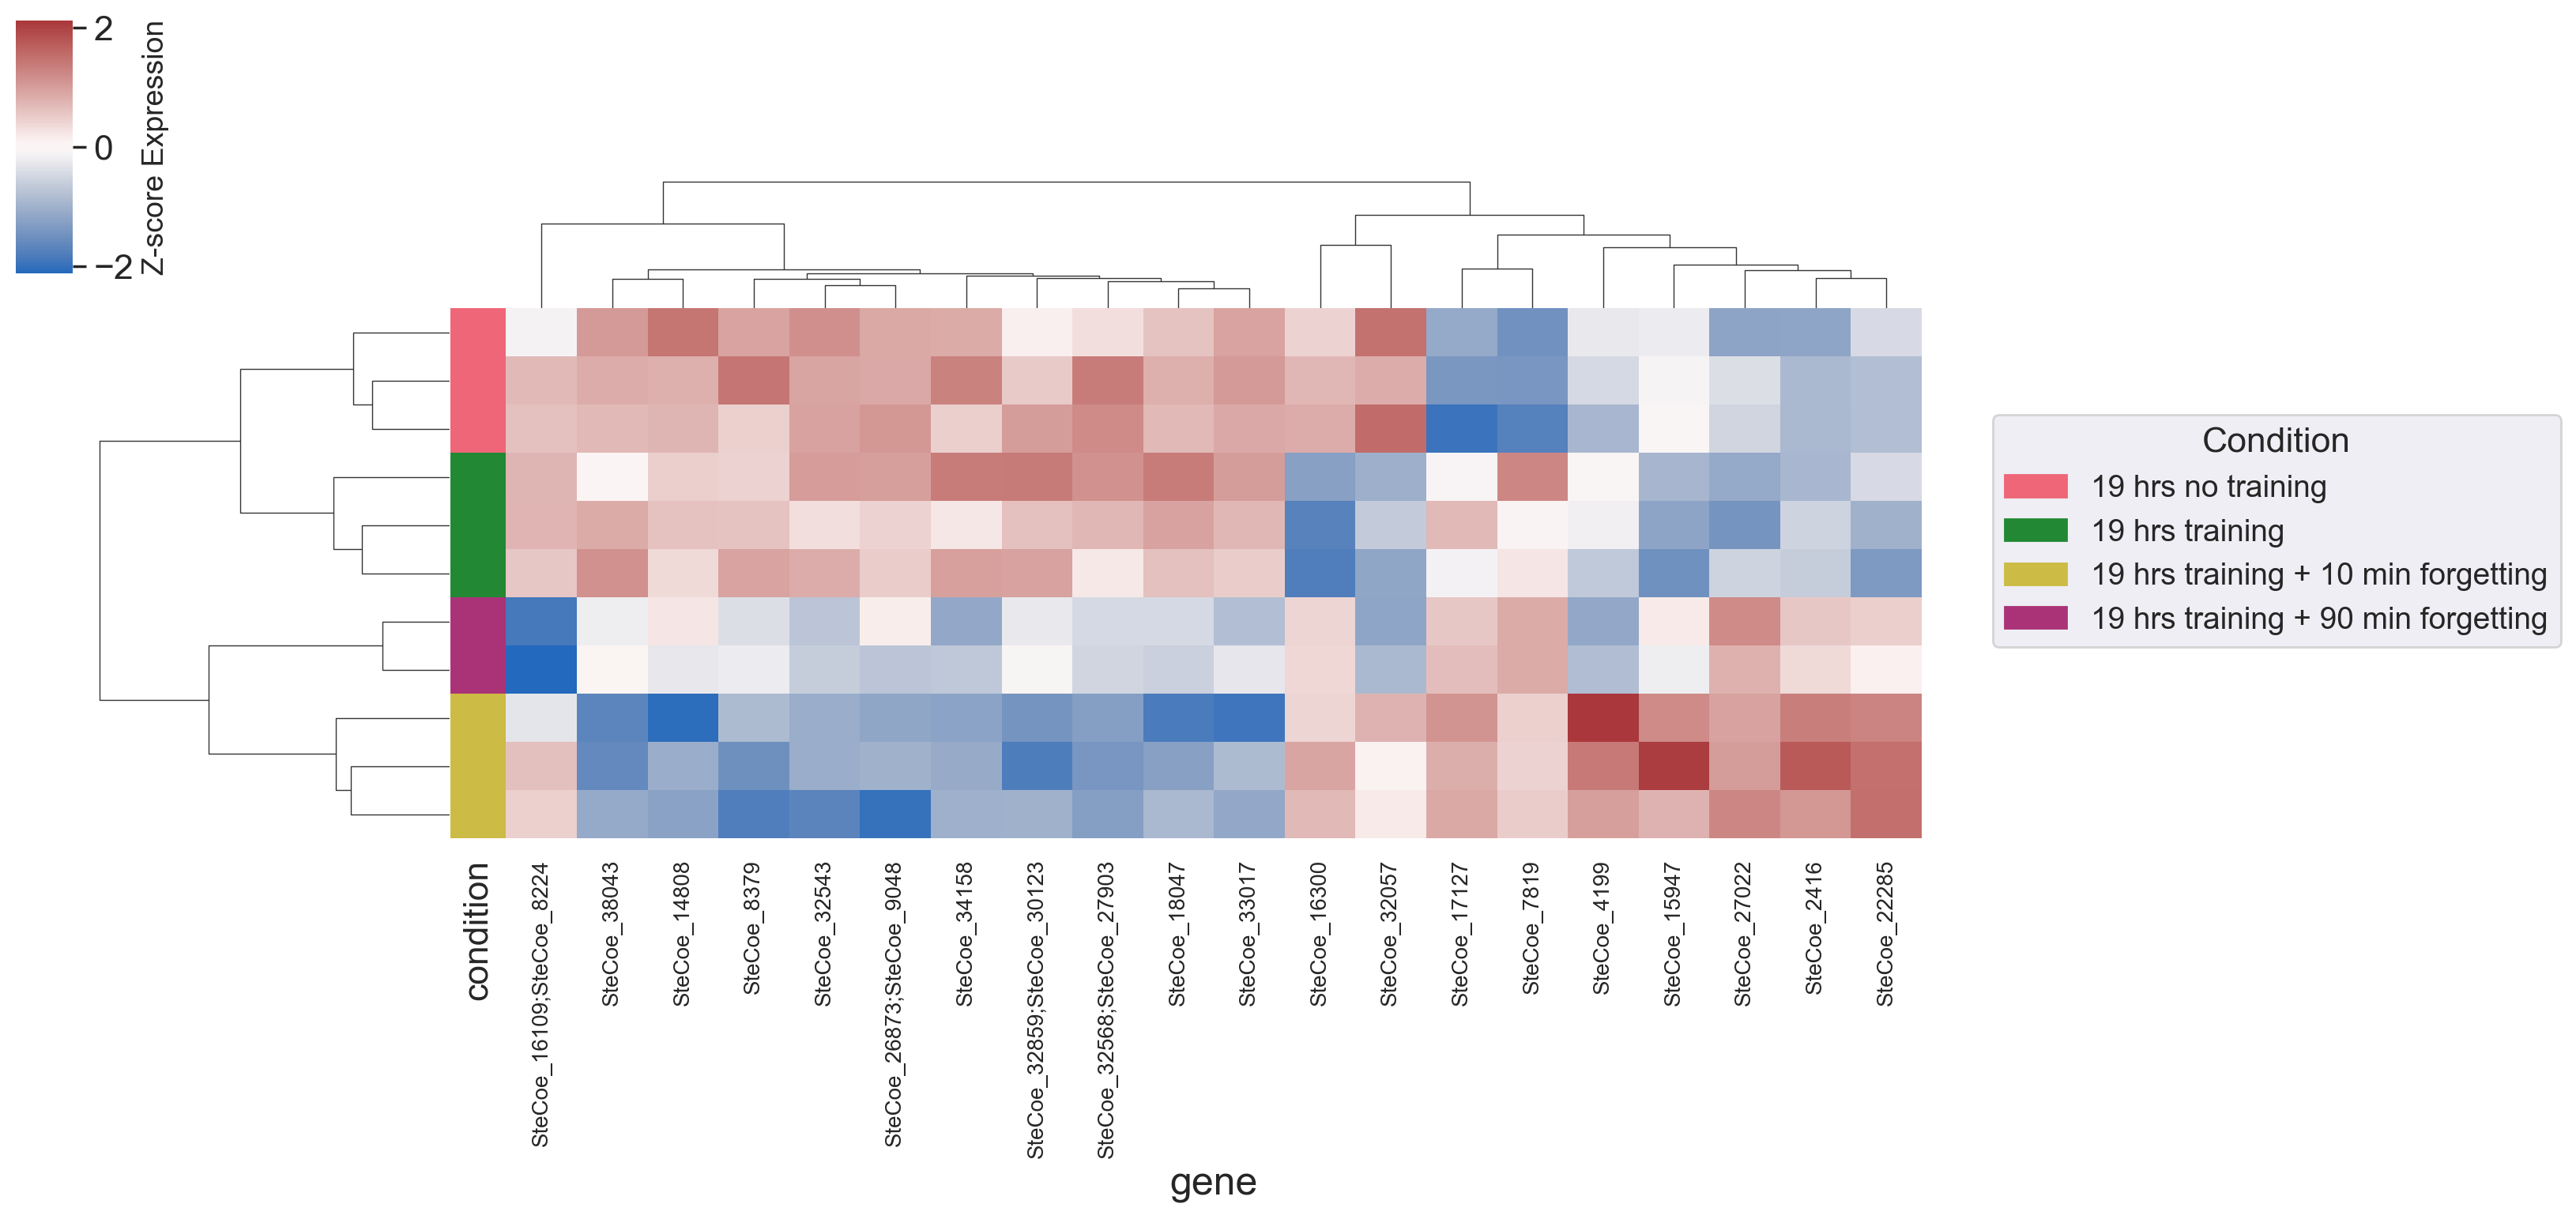

In [45]:
# get expression data for desired genes 
top_50_gene_names = top_50_genes[top_50_genes.qval < 0.3]['Gene']
top_50_expr = df_no0.loc[top_50_gene_names]

# z-score normalize 
top_50_expr_zscore = top_50_expr.apply(zscore, axis=1)

# map sample to the color 
row_colors = s2c_no0['condition'].map(color_dict)

# clustered heatmap by condition 
g = sns.clustermap(
    top_50_expr_zscore.T,  # Transpose to have samples as rows
    cmap="vlag",  # Color map for the heatmap
    annot=False,  # Disable annotations (set to True if needed)
    figsize=(12, 8),  # Size of the plot
    row_colors=row_colors,  # Color the rows based on conditions
    xticklabels = True, 
    yticklabels = False, 
    cbar_pos=(-0.02, 0.9, 0.03, 0.2), 
)

# colorbar label
g.cax.set_ylabel("Z-score Expression", fontsize=13.5, rotation=90)

# condition legend and position relative to z-score colorbar
handles = [mpatches.Patch(color=color_dict_no0[key], label=label_dict[key]) for key in color_dict_no0]
plt.legend(handles=handles, title="Condition", bbox_to_anchor=(45, -0.5), loc='upper right', fontsize = 14, title_fontsize = 16)

# x-axis/gene name settings 
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=10)  # Adjust fontsize as needed
plt.xticks([], rotation=0)

# Save the heatmap
plt.savefig("exp2_prot_no0_hm_ex_zscore.png", bbox_inches="tight", dpi=300)

# Show the plot
plt.show()


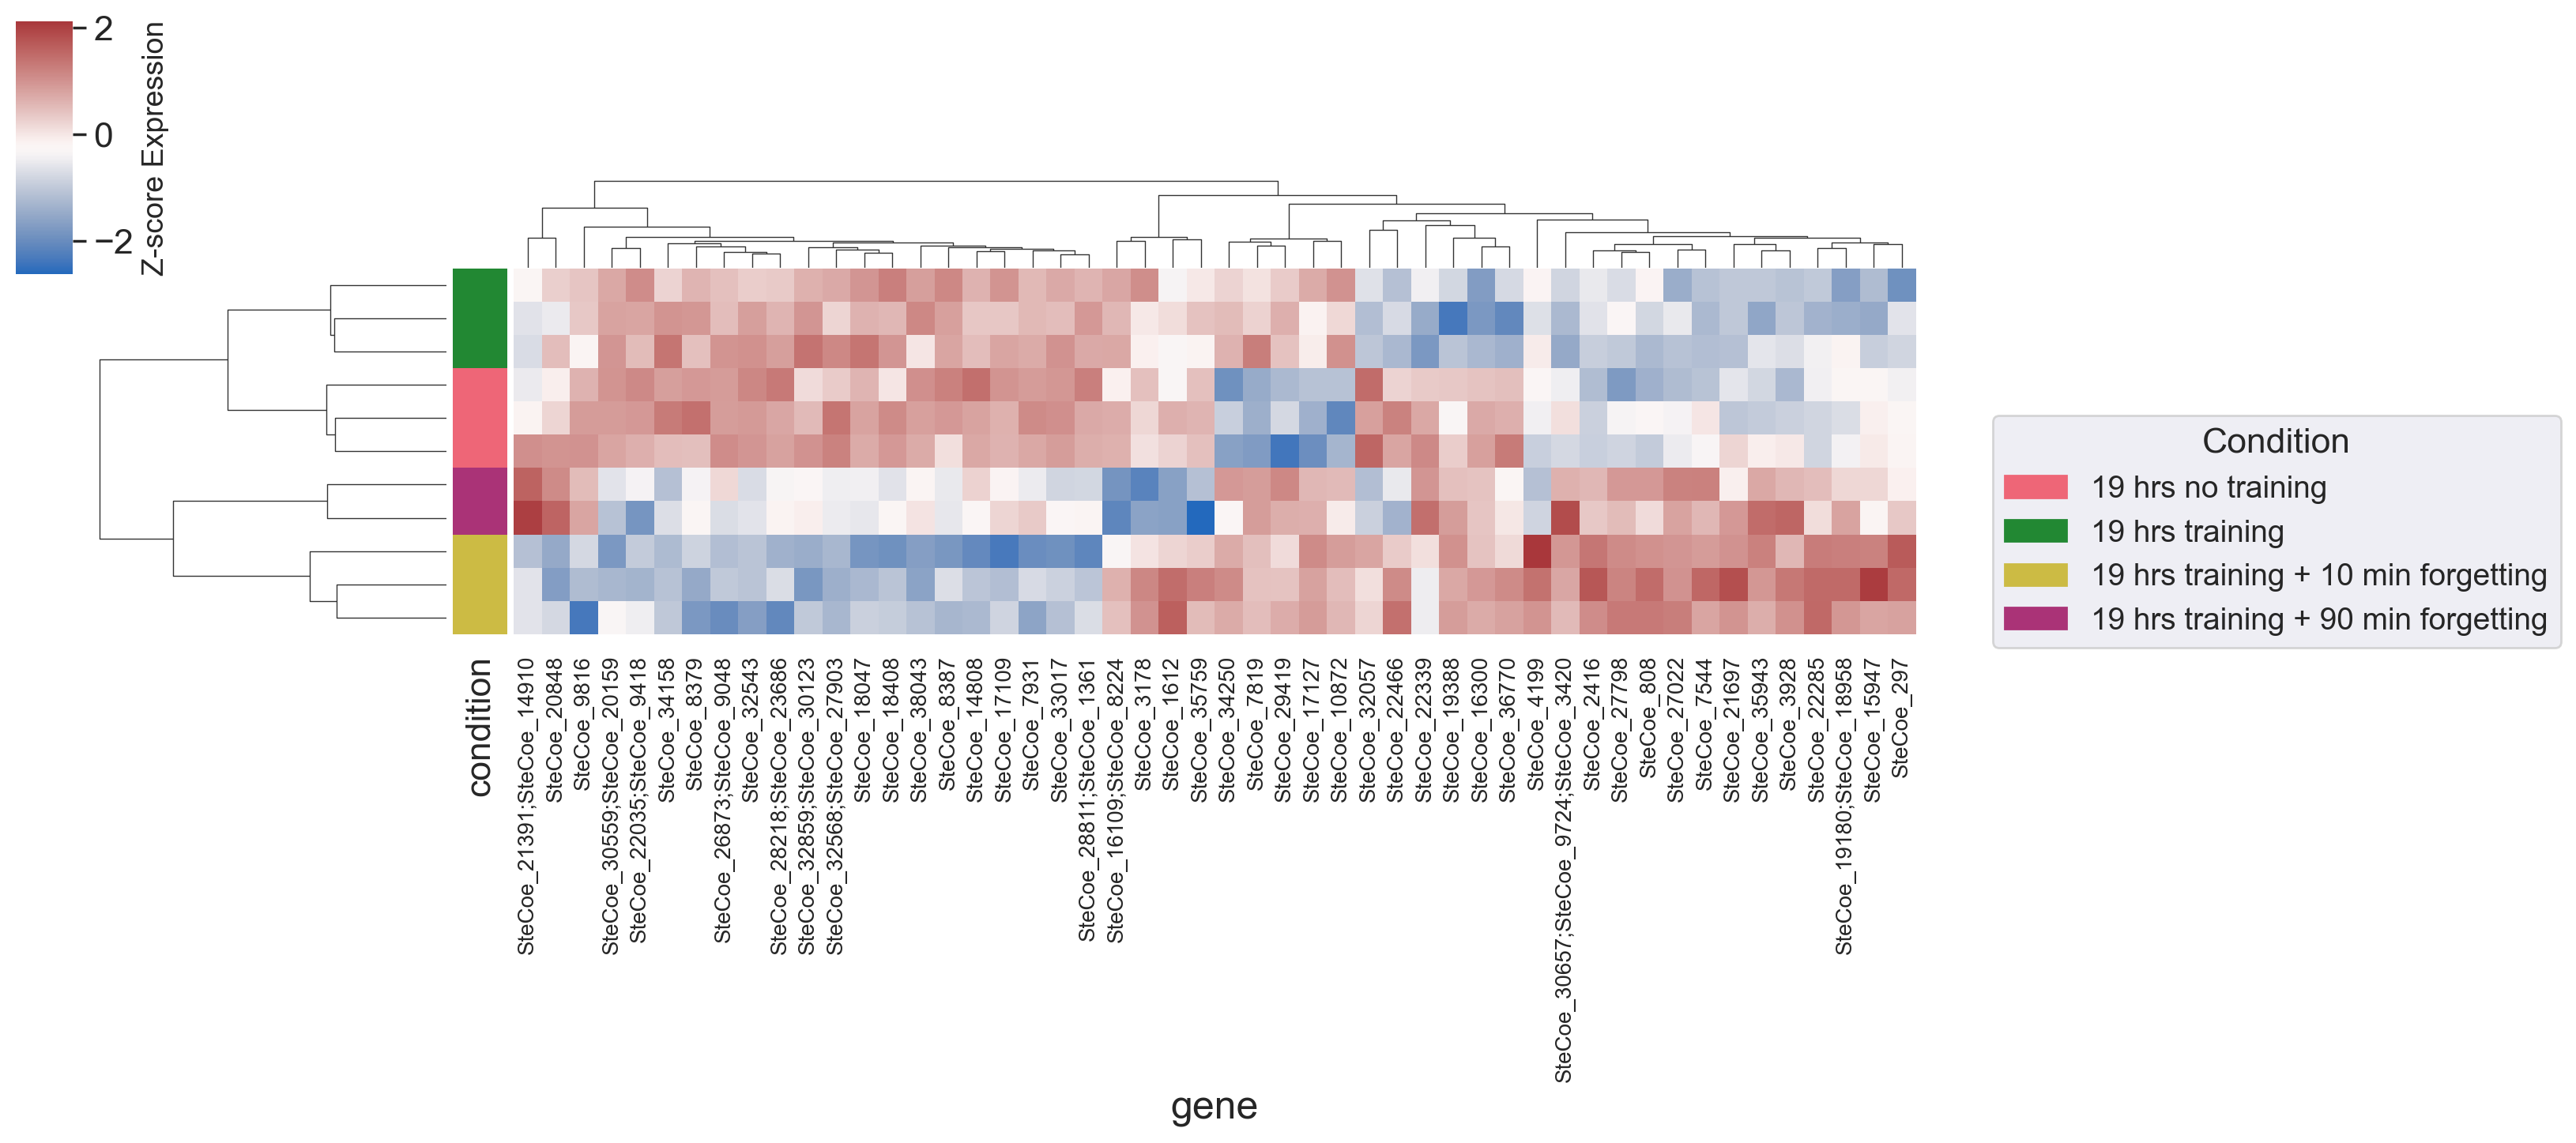

In [46]:
# get expression data for desired genes 
top_50_gene_names = top_50_genes['Gene']
top_50_expr = df_no0.loc[top_50_gene_names]

# z-score normalize 
top_50_expr_zscore = top_50_expr.apply(zscore, axis=1)

# map sample to the color 
row_colors = s2c_no0['condition'].map(color_dict)

# clustered heatmap by condition 
g = sns.clustermap(
    top_50_expr_zscore.T,  # Transpose to have samples as rows
    cmap="vlag",  # Color map for the heatmap
    annot=False,  # Disable annotations (set to True if needed)
    figsize=(12, 8),  # Size of the plot
    row_colors=row_colors,  # Color the rows based on conditions
    xticklabels = True, 
    yticklabels = False, 
    cbar_pos=(-0.02, 0.9, 0.03, 0.2), 
)

# colorbar label
g.cax.set_ylabel("Z-score Expression", fontsize=13.5, rotation=90)

# condition legend and position relative to z-score colorbar
handles = [mpatches.Patch(color=color_dict_no0[key], label=label_dict[key]) for key in color_dict_no0]
plt.legend(handles=handles, title="Condition", bbox_to_anchor=(45, -0.5), loc='upper right', fontsize = 14, title_fontsize = 16)

# x-axis/gene name settings 
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=10)  # Adjust fontsize as needed
plt.xticks([], rotation=0)

# Save the heatmap
plt.savefig("exp2_prot_no0_top50pval_hm_ex_zscore.png", bbox_inches="tight", dpi=300)

# Show the plot
plt.show()


## Single gene plots

In [47]:
# specific gene
specific_gene = 'SteCoe_7819'  # gene of interest
specific_gene_expr = df.loc[specific_gene]

# melt df 
specific_gene_expr_df = specific_gene_expr.reset_index()
specific_gene_expr_df.columns = ['sample', 'expression']

specific_gene_expr_df['condition'] = specific_gene_expr_df['sample'].map(s2c["condition"])
specific_gene_expr_df['condition'] = specific_gene_expr_df['condition'].map(label_dict)

# add label to df 
#specific_gene_expr_df['group'] = specific_gene_expr_df['condition'].map(new_labels)

# fix index
s2c_reset = s2c.reset_index()  # Reset the index so 'sample' becomes a column
specific_gene_expr_df = specific_gene_expr_df.merge(s2c_reset[['sample', 'condition']], on='sample')

In [48]:
# Remap color_dict_no0 to match the new condition labels
color_dict_named = {label_dict[k]: v for k, v in color_dict.items() if k in label_dict}

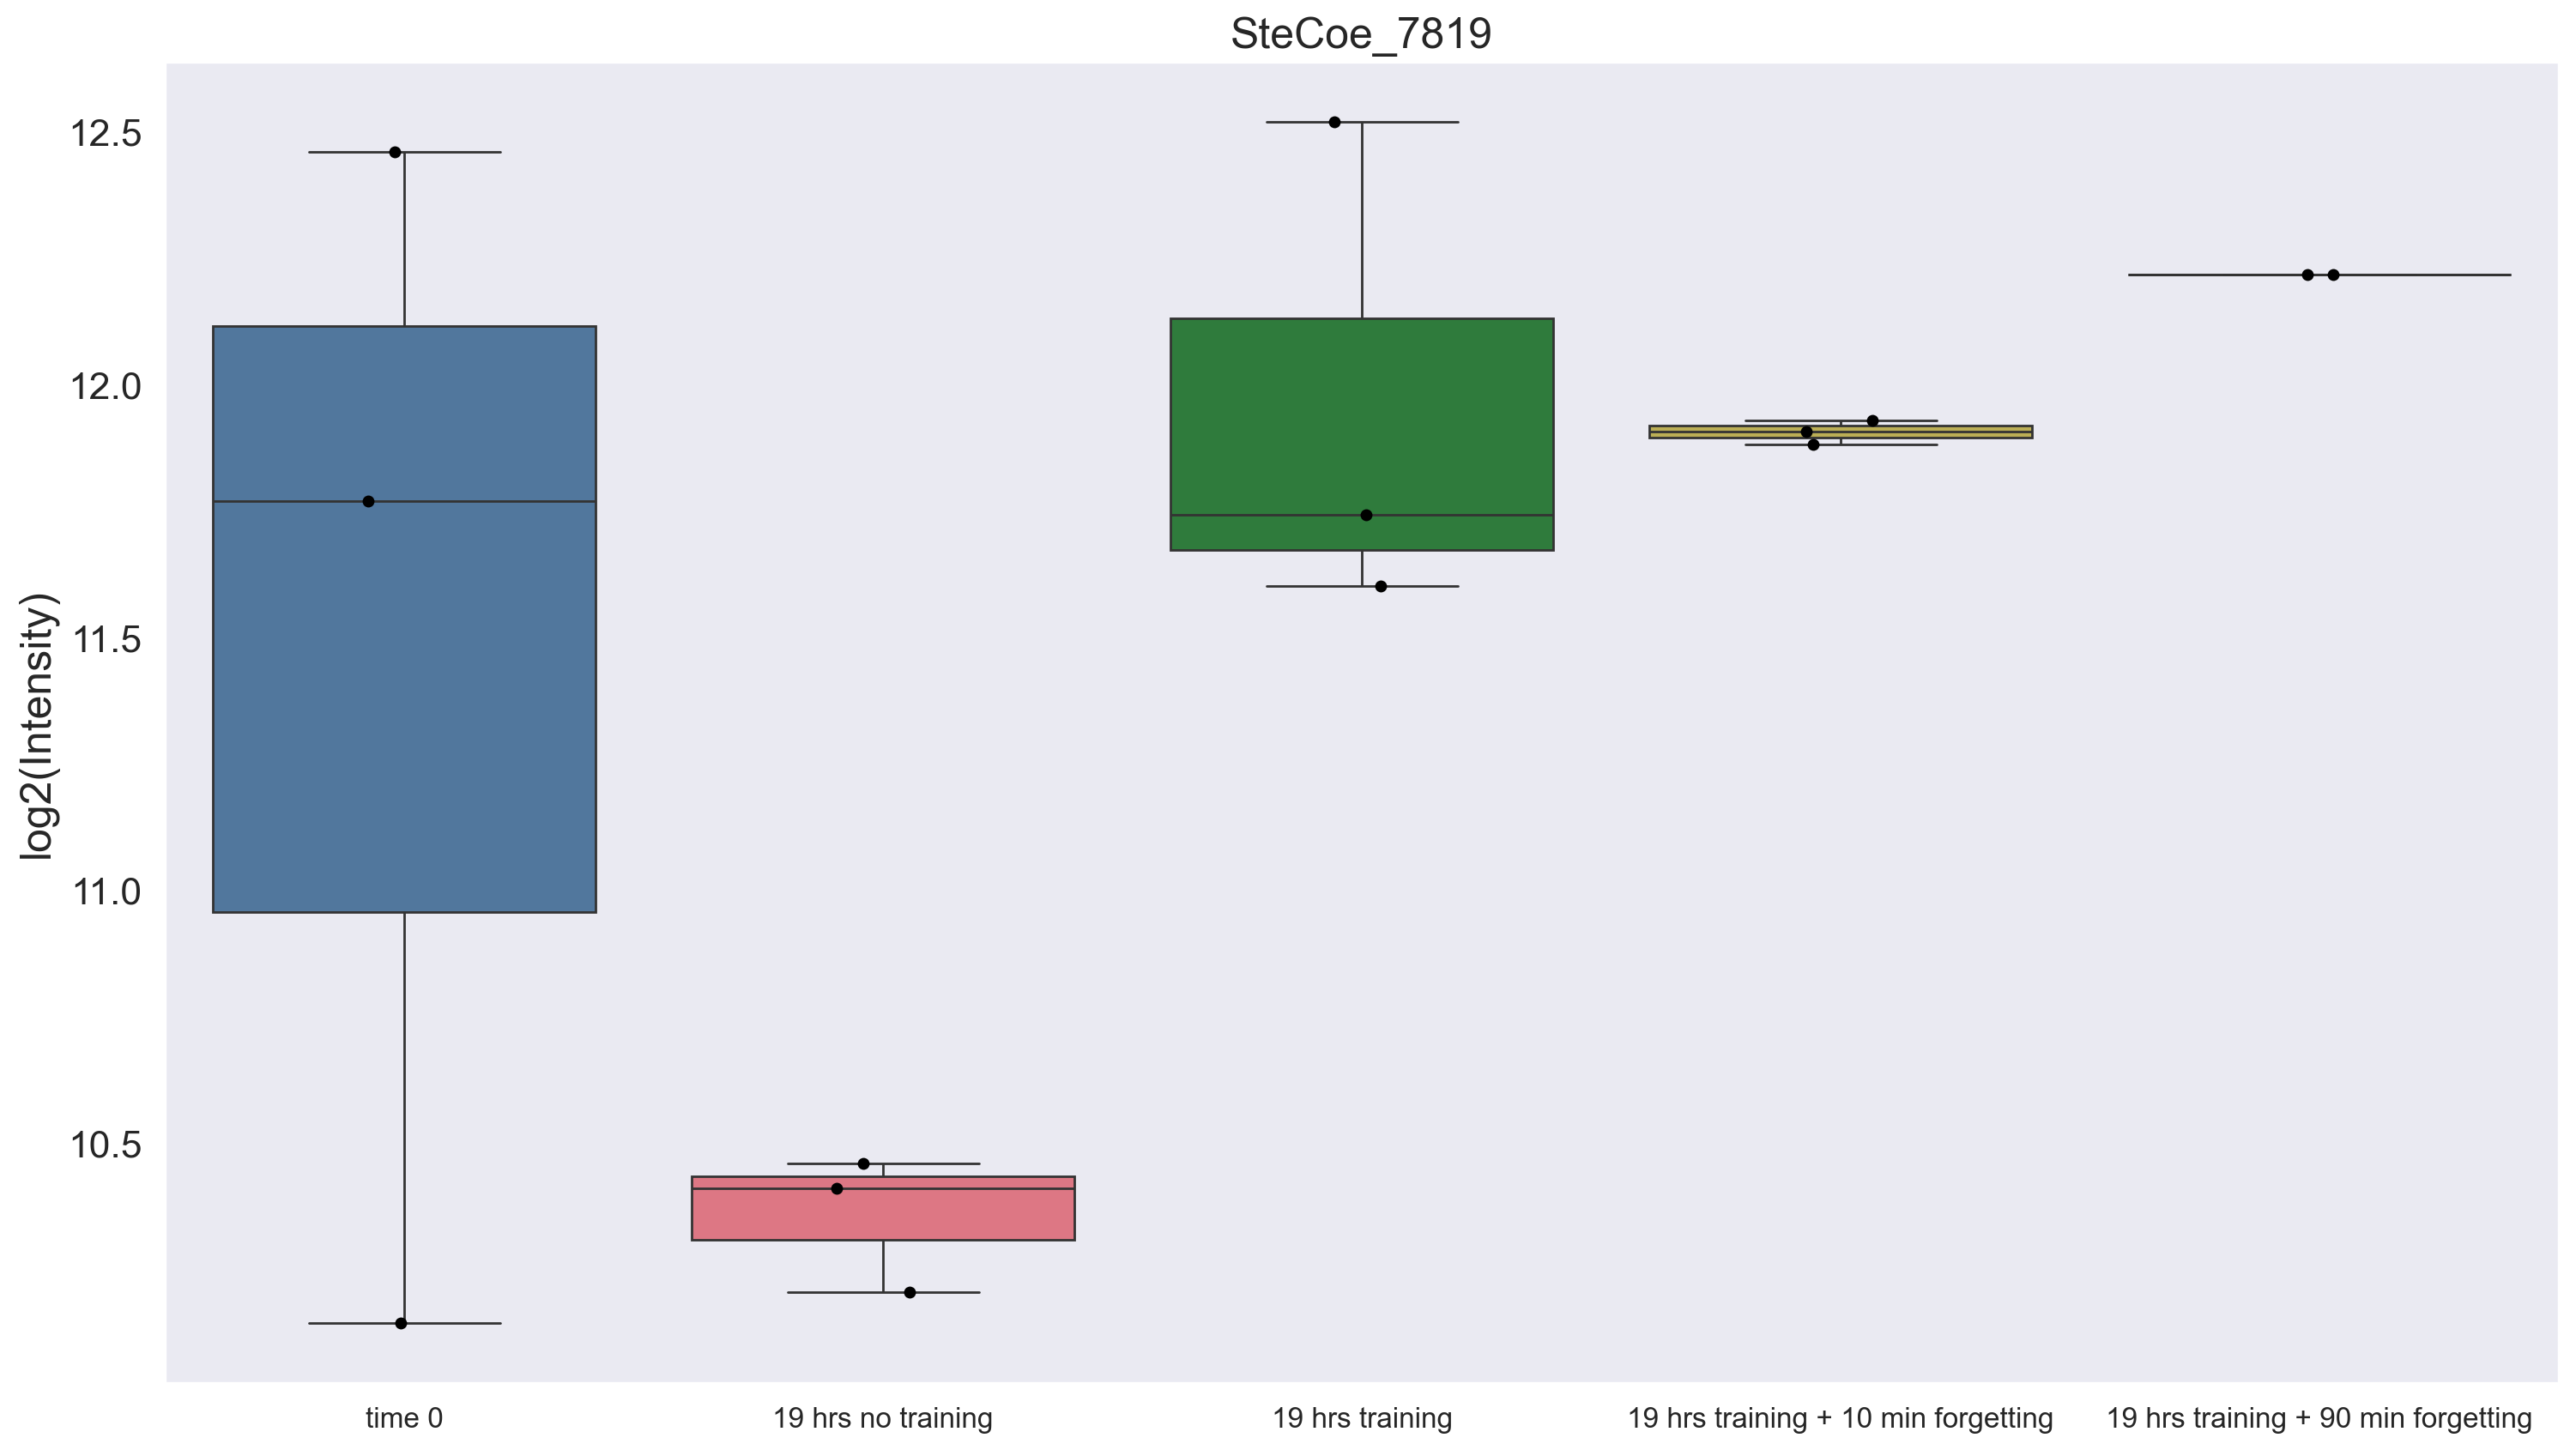

In [49]:
# plot

order = list(color_dict_named.keys())

plt.figure(figsize=(18, 10))
sns.boxplot(data=specific_gene_expr_df, 
            x="condition_x", 
            y="expression", 
            hue = 'condition_x', 
            palette = color_dict_named, 
            order = order)
sns.stripplot(x='condition_x', 
              y='expression', 
              data=specific_gene_expr_df, 
              color='black',
              order = order)
plt.xticks(fontsize=12)
plt.title(specific_gene)
plt.ylabel("log2(Intensity)", fontsize=18)
plt.xlabel("")
plt.savefig('exp2_prot_7819.png', dpi= 300, bbox_inches = 'tight')

In [50]:
# specific gene
specific_gene = 'SteCoe_32292'  # gene of interest
specific_gene_expr = df.loc[specific_gene]

# melt df 
specific_gene_expr_df = specific_gene_expr.reset_index()
specific_gene_expr_df.columns = ['sample', 'expression']

specific_gene_expr_df['condition'] = specific_gene_expr_df['sample'].map(s2c["condition"])
specific_gene_expr_df['condition'] = specific_gene_expr_df['condition'].map(label_dict)

# add label to df 
#specific_gene_expr_df['group'] = specific_gene_expr_df['condition'].map(new_labels)

# fix index
s2c_reset = s2c.reset_index()  # Reset the index so 'sample' becomes a column
specific_gene_expr_df = specific_gene_expr_df.merge(s2c_reset[['sample', 'condition']], on='sample')

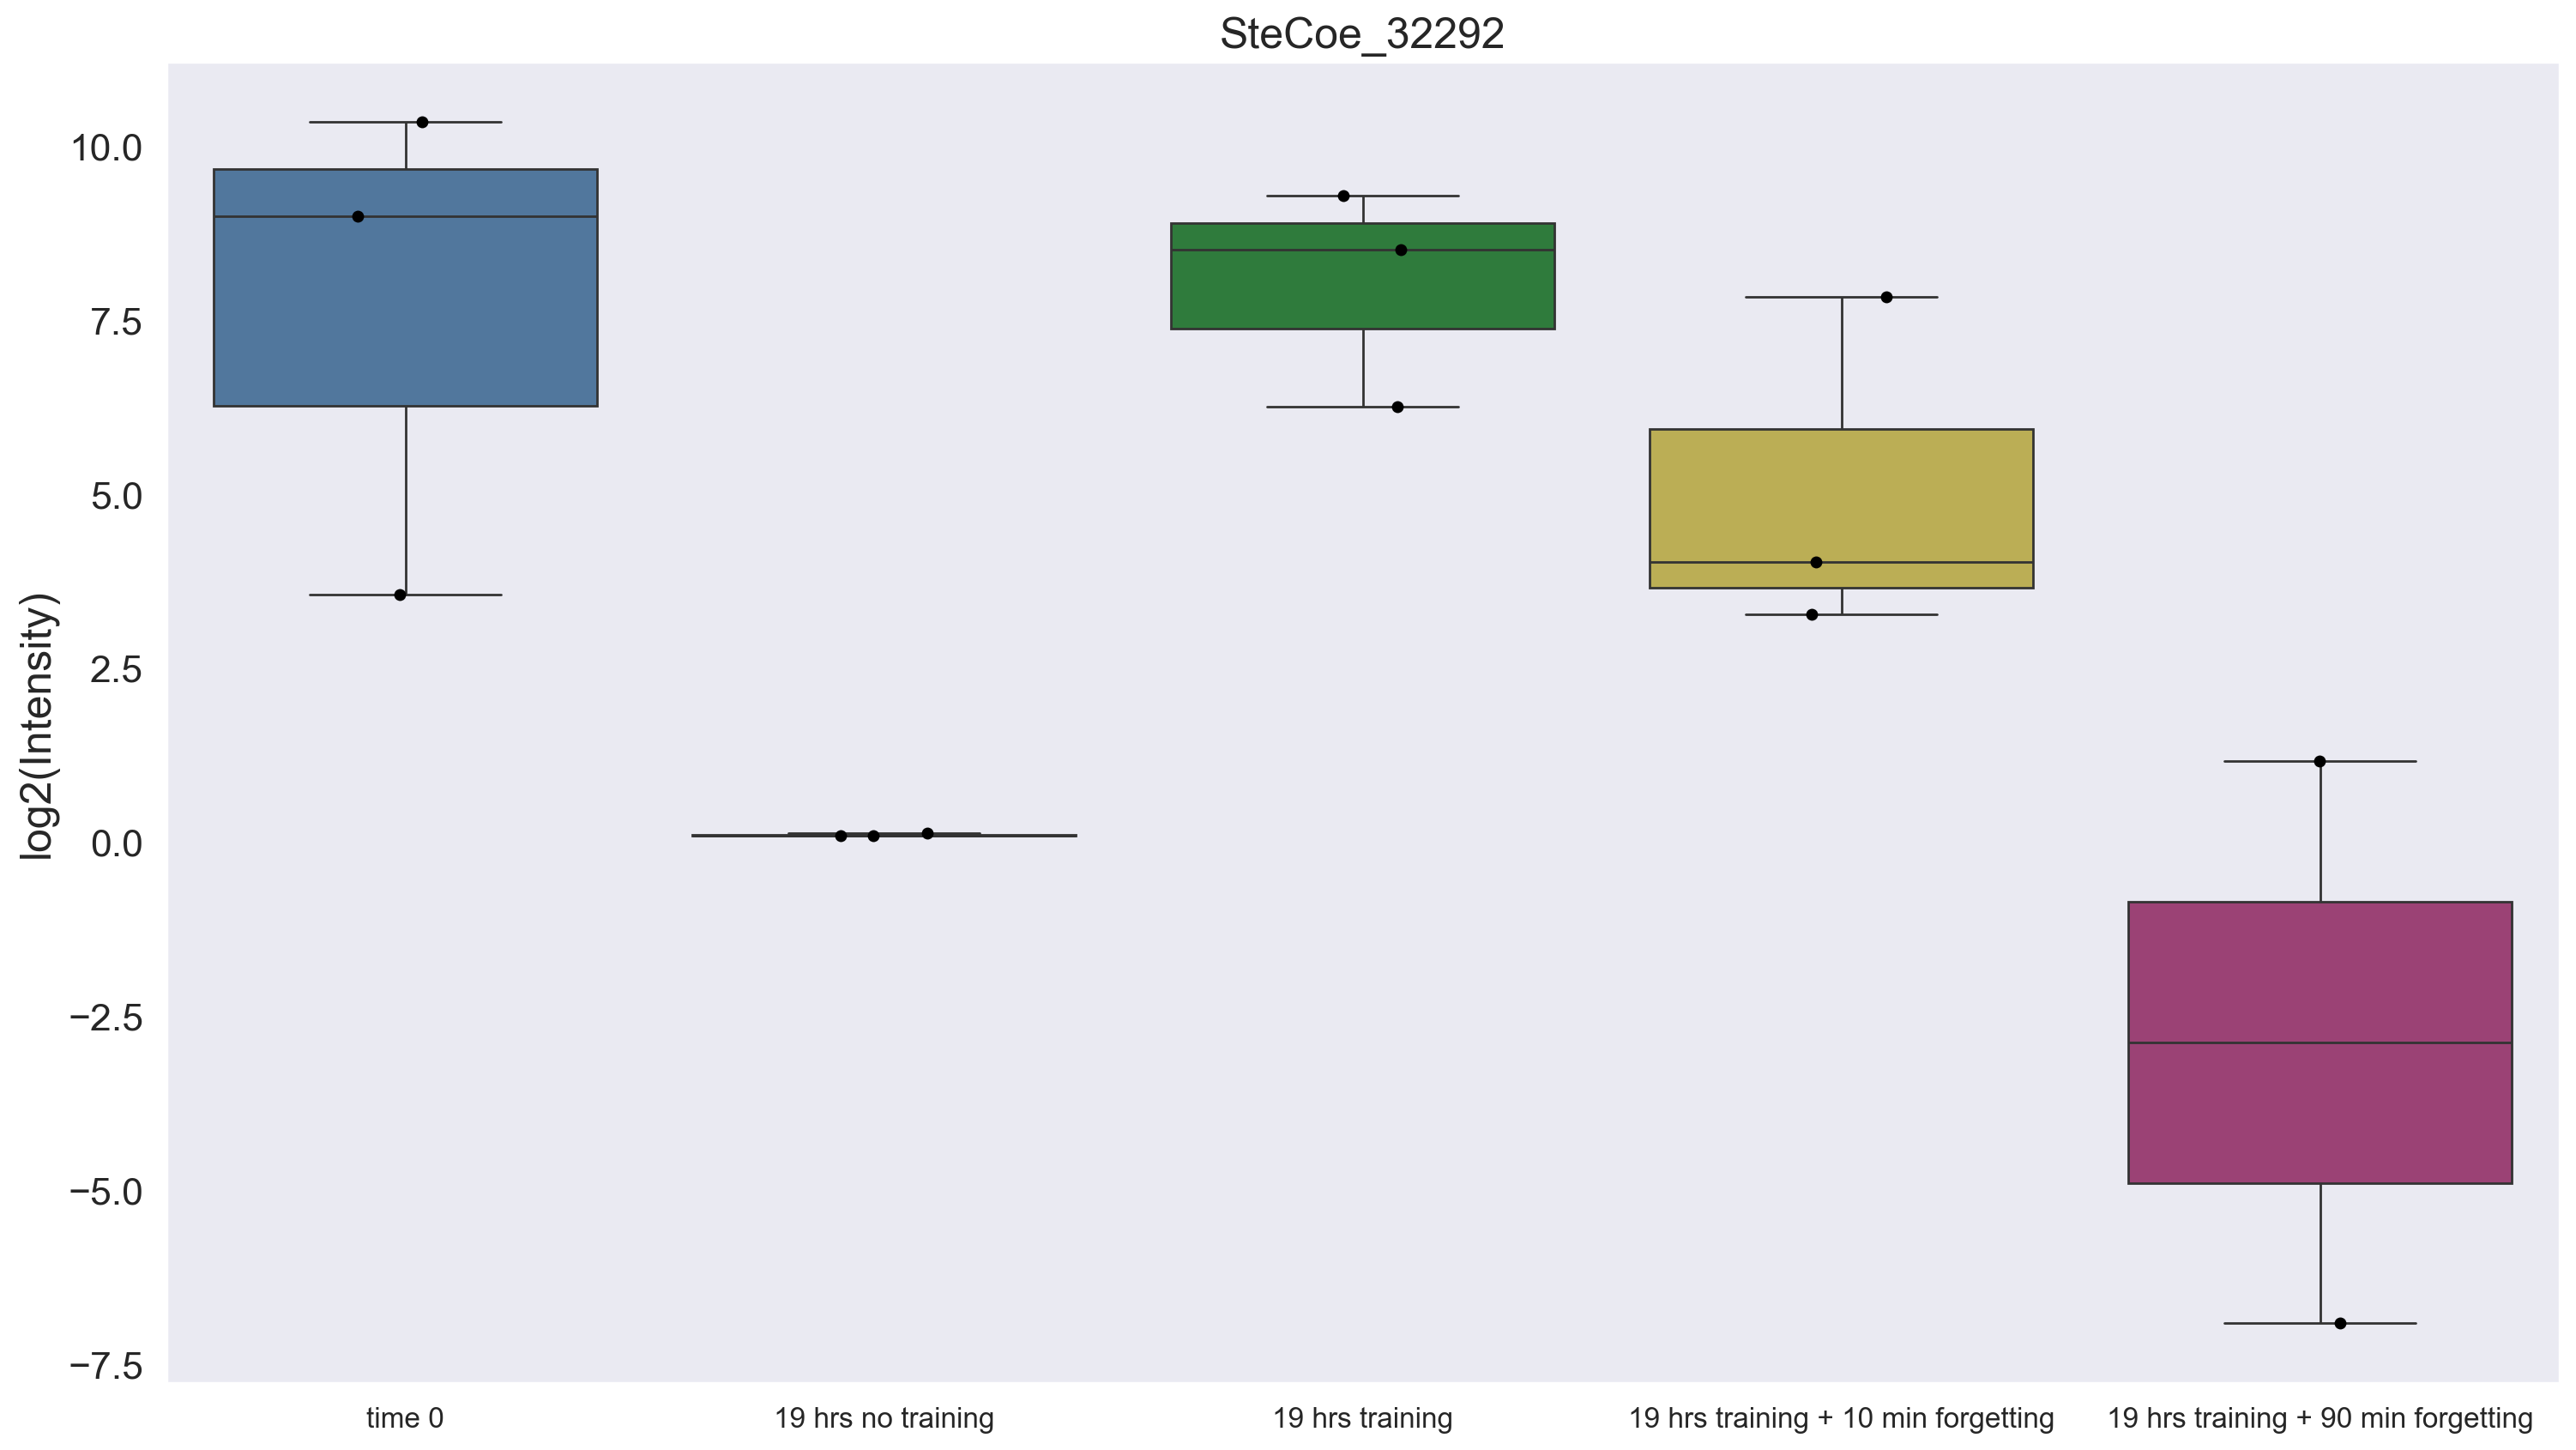

In [51]:
# plot

order = list(color_dict_named.keys())

plt.figure(figsize=(18, 10))
sns.boxplot(data=specific_gene_expr_df, 
            x="condition_x", 
            y="expression", 
            hue = 'condition_x', 
            palette = color_dict_named, 
            order = order)
sns.stripplot(x='condition_x', 
              y='expression', 
              data=specific_gene_expr_df, 
              color='black',
              order = order)
plt.xticks(fontsize=12)
plt.title(specific_gene)
plt.ylabel("log2(Intensity)", fontsize=18)
plt.xlabel("")
plt.savefig('exp2_prot_32292.png', dpi= 300, bbox_inches = 'tight')

In [52]:
# specific gene
specific_gene = 'SteCoe_36256'  # gene of interest
specific_gene_expr = df.loc[specific_gene]

# melt df 
specific_gene_expr_df = specific_gene_expr.reset_index()
specific_gene_expr_df.columns = ['sample', 'expression']

specific_gene_expr_df['condition'] = specific_gene_expr_df['sample'].map(s2c["condition"])
specific_gene_expr_df['condition'] = specific_gene_expr_df['condition'].map(label_dict)

# add label to df 
#specific_gene_expr_df['group'] = specific_gene_expr_df['condition'].map(new_labels)

# fix index
s2c_reset = s2c.reset_index()  # Reset the index so 'sample' becomes a column
specific_gene_expr_df = specific_gene_expr_df.merge(s2c_reset[['sample', 'condition']], on='sample')

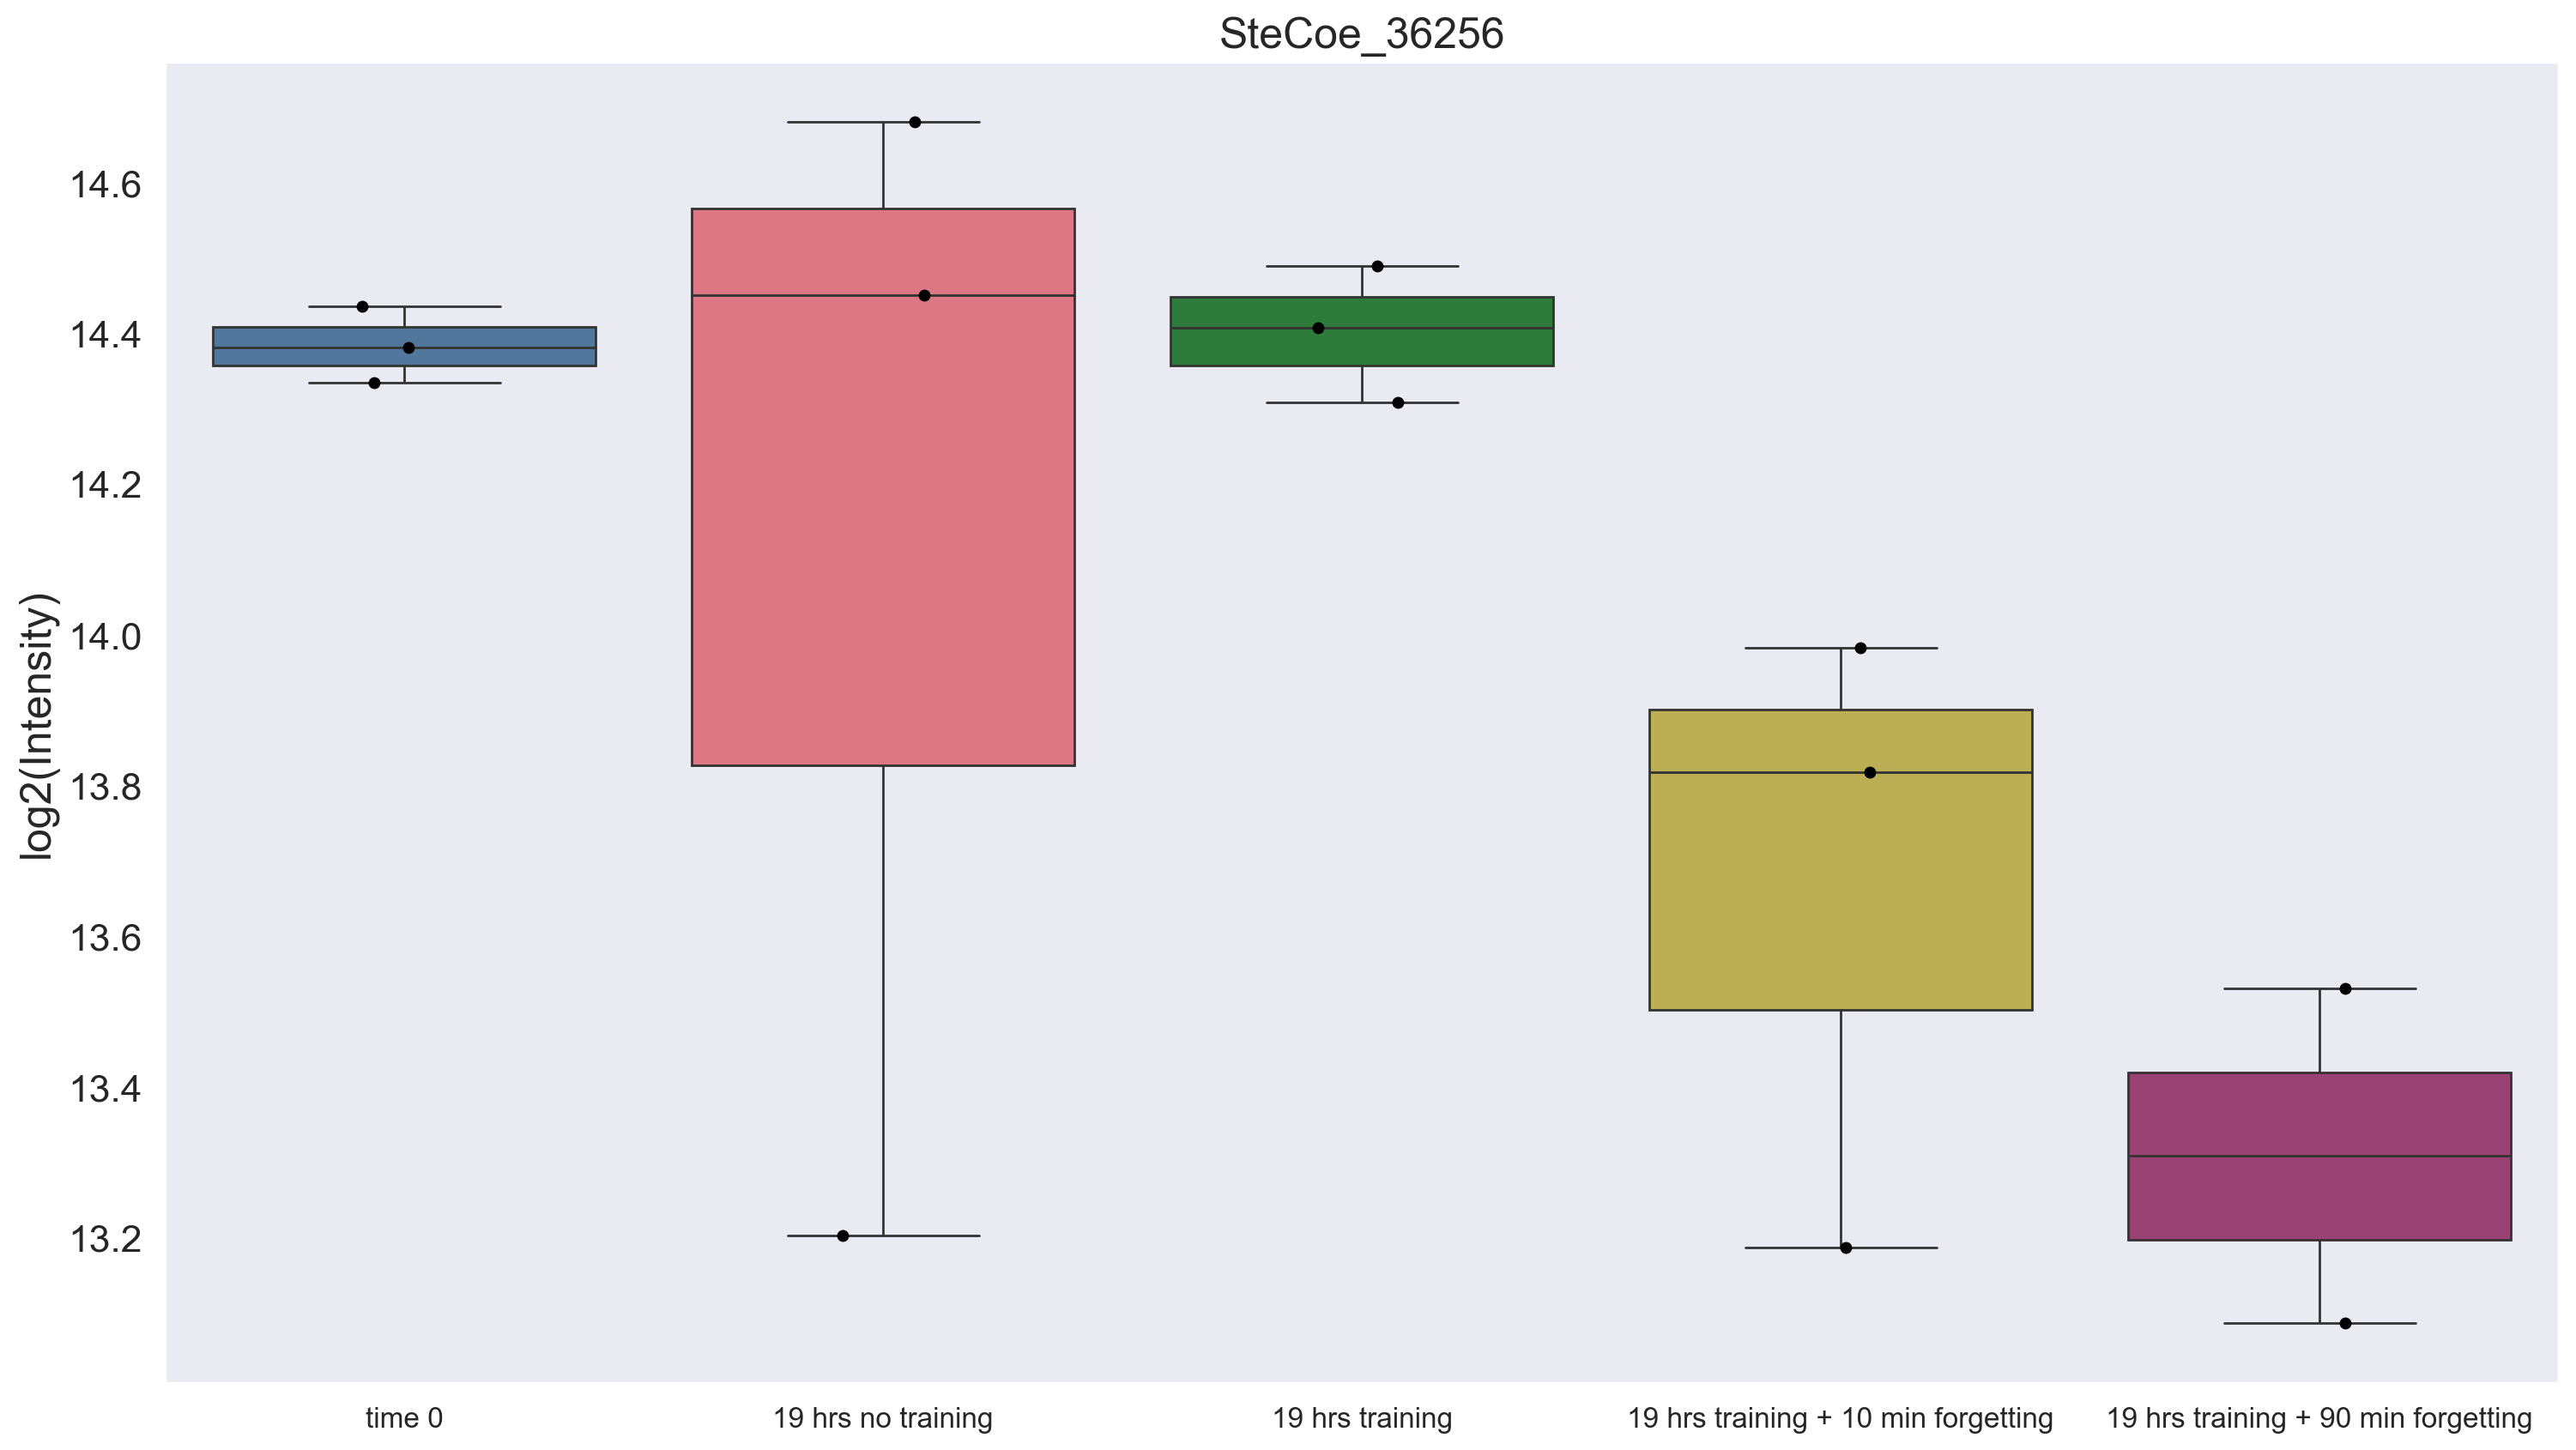

In [53]:
# plot

order = list(color_dict_named.keys())

plt.figure(figsize=(18, 10))
sns.boxplot(data=specific_gene_expr_df, 
            x="condition_x", 
            y="expression", 
            hue = 'condition_x', 
            palette = color_dict_named, 
            order = order)
sns.stripplot(x='condition_x', 
              y='expression', 
              data=specific_gene_expr_df, 
              color='black',
              order = order)
plt.xticks(fontsize=12)
plt.title(specific_gene)
plt.ylabel("log2(Intensity)", fontsize=18)
plt.xlabel("")
plt.savefig('exp2_prot_36256.png', dpi= 300, bbox_inches = 'tight')

In [54]:
# specific gene
specific_gene = 'SteCoe_22339'  # gene of interest
specific_gene_expr = df.loc[specific_gene]

# melt df 
specific_gene_expr_df = specific_gene_expr.reset_index()
specific_gene_expr_df.columns = ['sample', 'expression']

specific_gene_expr_df['condition'] = specific_gene_expr_df['sample'].map(s2c["condition"])
specific_gene_expr_df['condition'] = specific_gene_expr_df['condition'].map(label_dict)

# add label to df 
#specific_gene_expr_df['group'] = specific_gene_expr_df['condition'].map(new_labels)

# fix index
s2c_reset = s2c.reset_index()  # Reset the index so 'sample' becomes a column
specific_gene_expr_df = specific_gene_expr_df.merge(s2c_reset[['sample', 'condition']], on='sample')

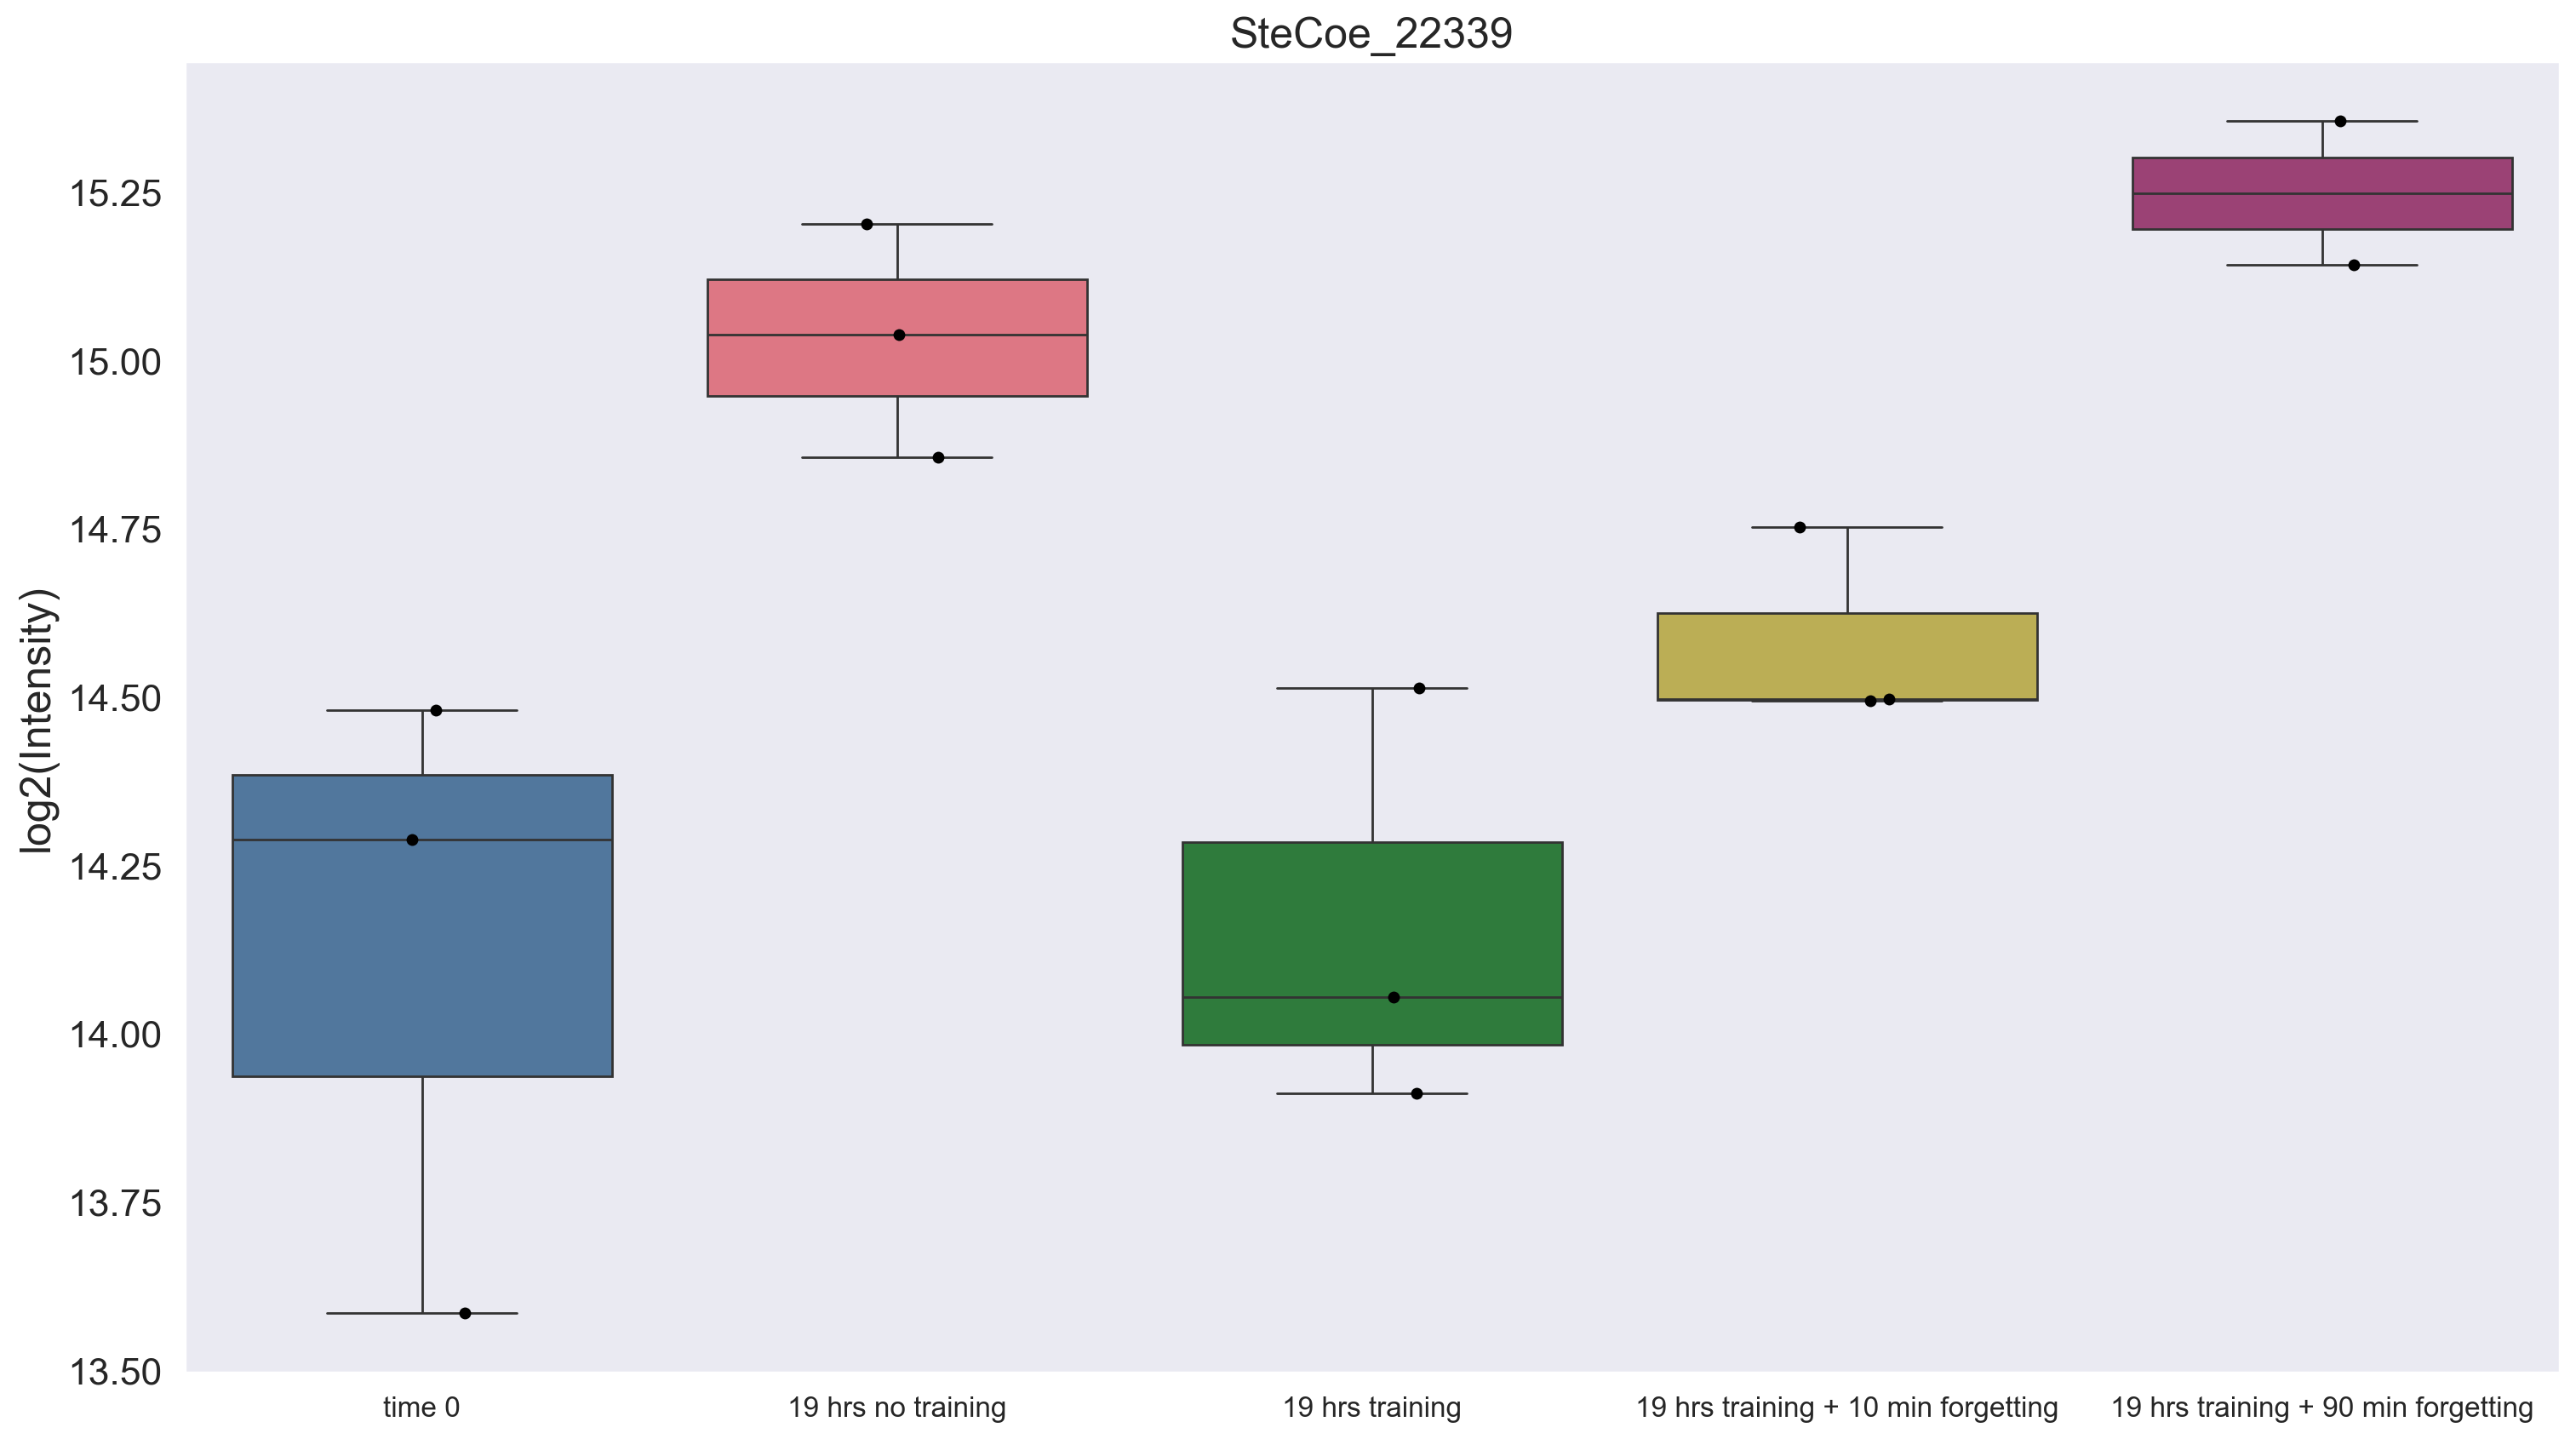

In [55]:
# plot

order = list(color_dict_named.keys())

plt.figure(figsize=(18, 10))
sns.boxplot(data=specific_gene_expr_df, 
            x="condition_x", 
            y="expression", 
            hue = 'condition_x', 
            palette = color_dict_named, 
            order = order)
sns.stripplot(x='condition_x', 
              y='expression', 
              data=specific_gene_expr_df, 
              color='black',
              order = order)
plt.xticks(fontsize=12)
plt.title(specific_gene)
plt.ylabel("log2(Intensity)", fontsize=18)
plt.xlabel("")
plt.savefig('exp2_prot_22339.png', dpi= 300, bbox_inches = 'tight')

In [56]:
# specific gene
specific_gene = 'SteCoe_2157'  # gene of interest
specific_gene_expr = df.loc[specific_gene]

# melt df 
specific_gene_expr_df = specific_gene_expr.reset_index()
specific_gene_expr_df.columns = ['sample', 'expression']

specific_gene_expr_df['condition'] = specific_gene_expr_df['sample'].map(s2c["condition"])
specific_gene_expr_df['condition'] = specific_gene_expr_df['condition'].map(label_dict)

# add label to df 
#specific_gene_expr_df['group'] = specific_gene_expr_df['condition'].map(new_labels)

# fix index
s2c_reset = s2c.reset_index()  # Reset the index so 'sample' becomes a column
specific_gene_expr_df = specific_gene_expr_df.merge(s2c_reset[['sample', 'condition']], on='sample')

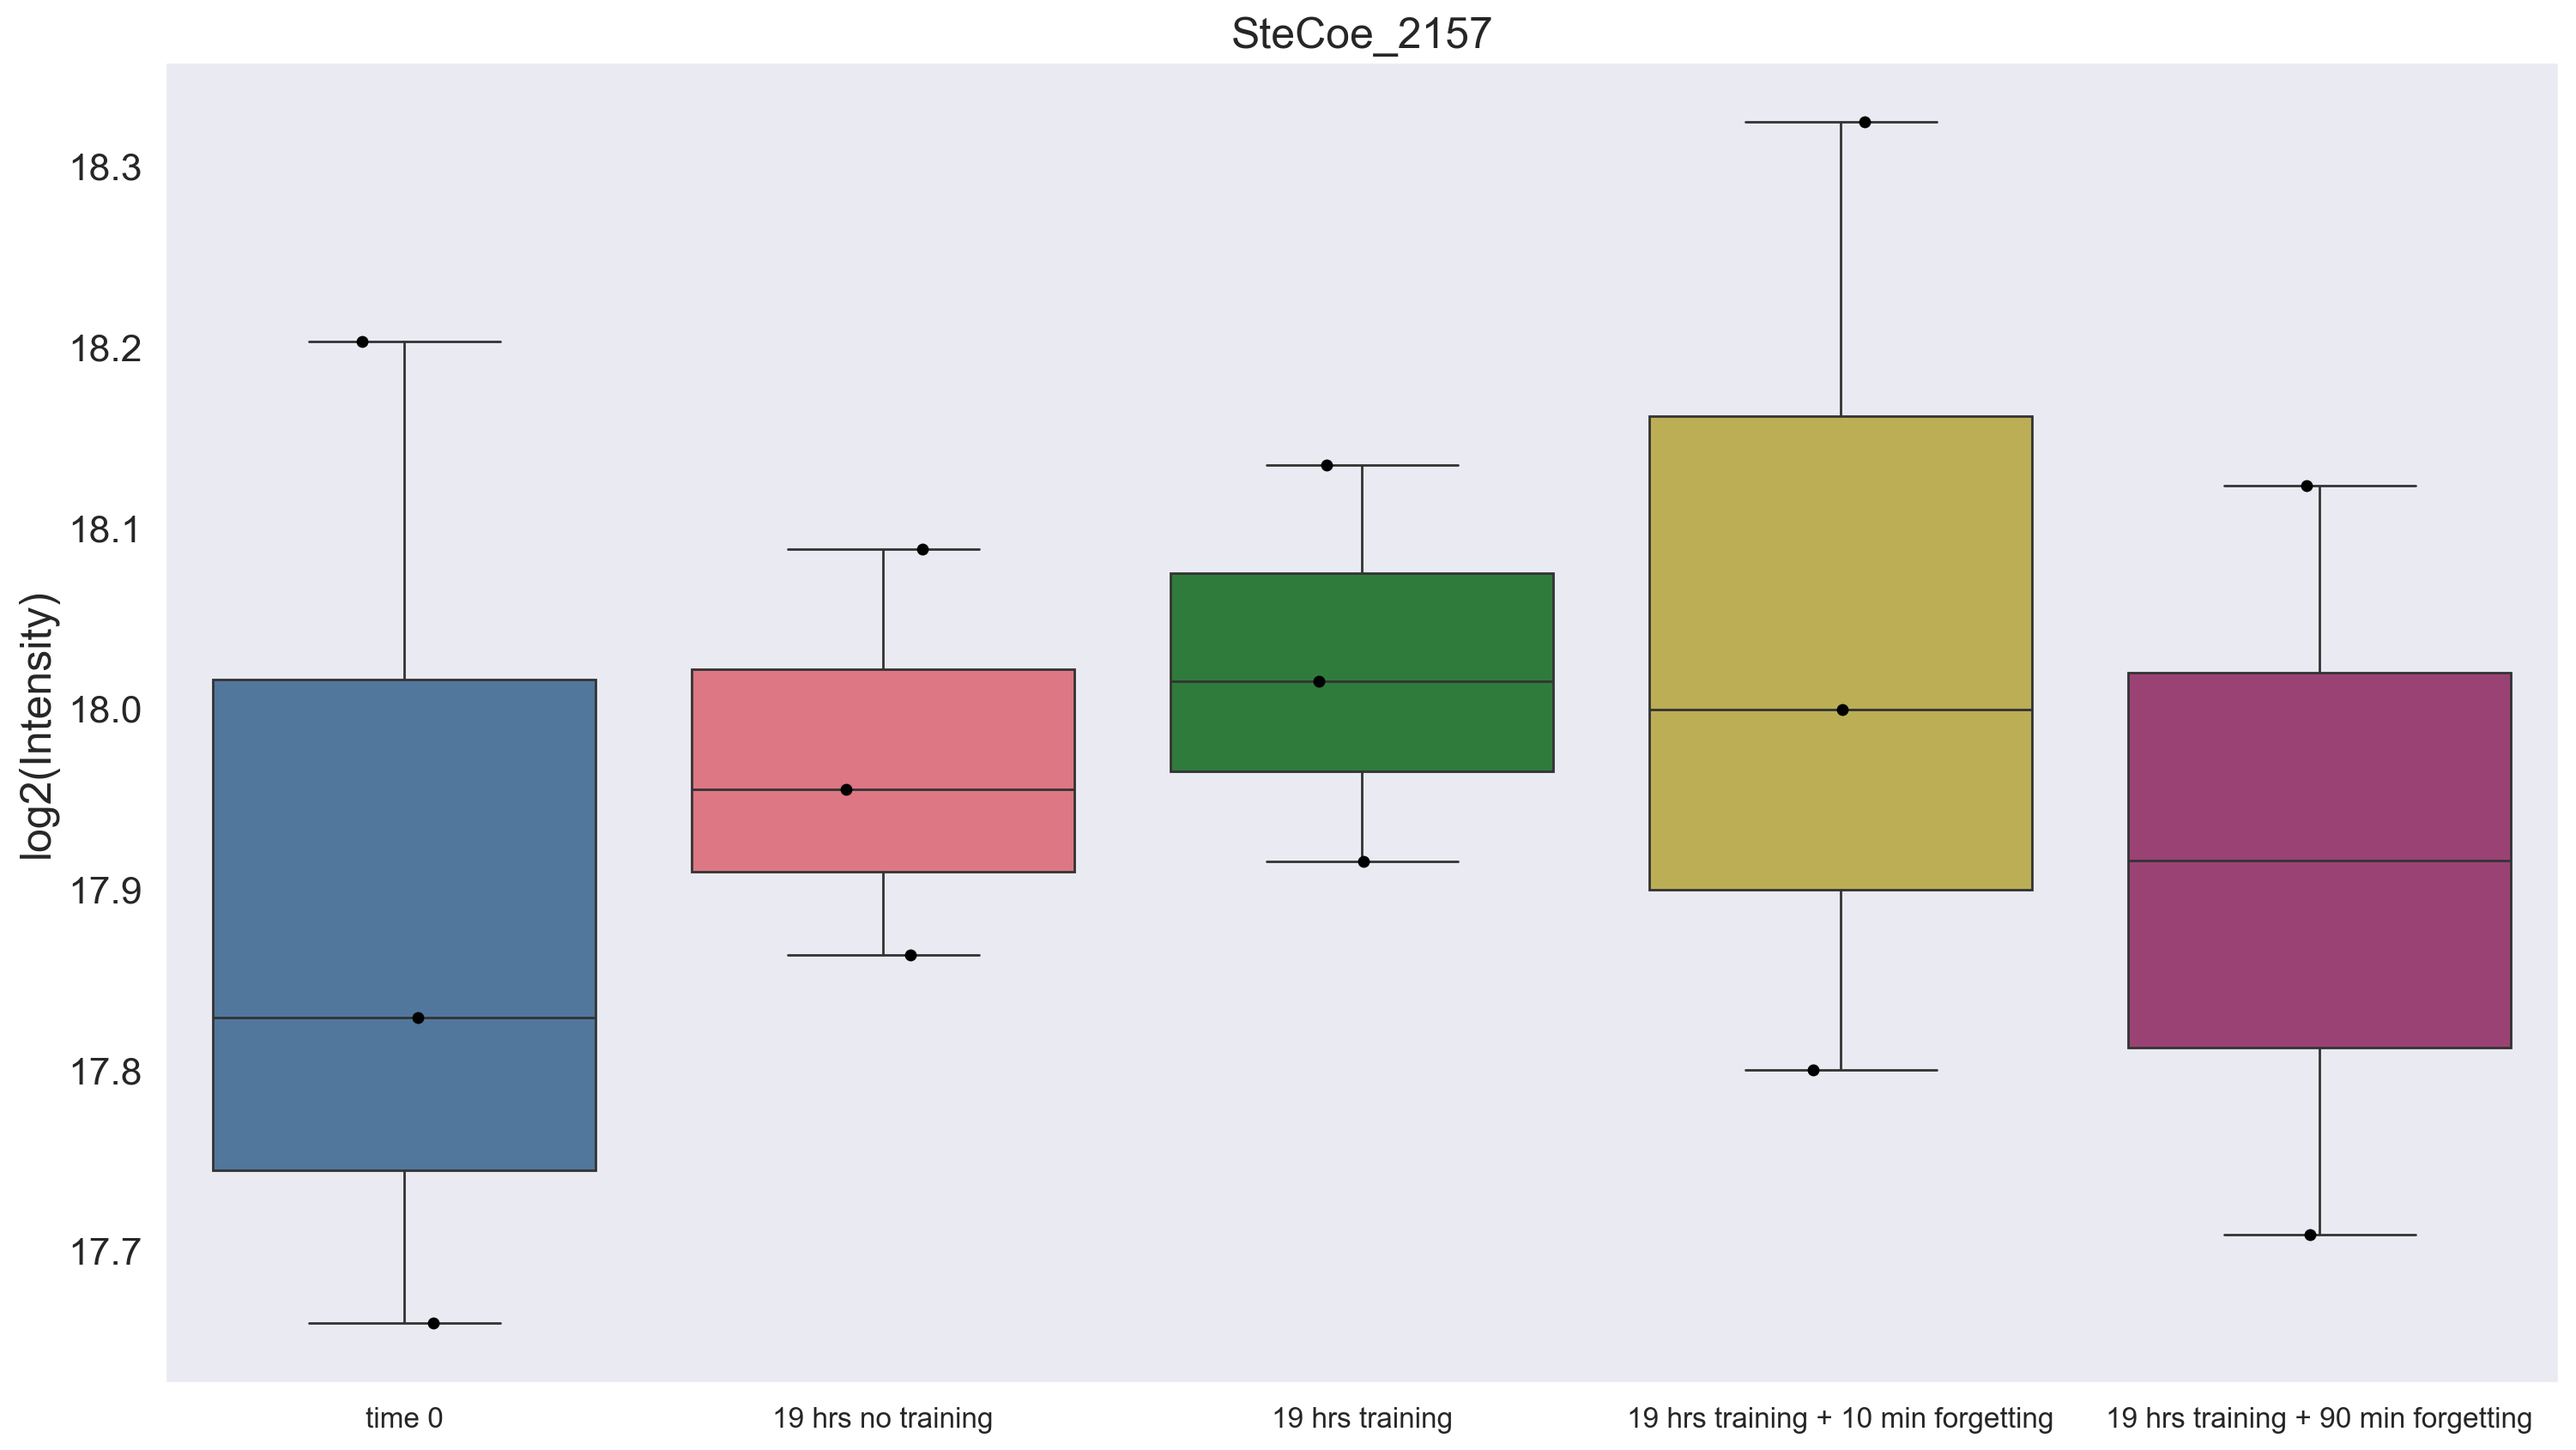

In [57]:
# plot

order = list(color_dict_named.keys())

plt.figure(figsize=(18, 10))
sns.boxplot(data=specific_gene_expr_df, 
            x="condition_x", 
            y="expression", 
            hue = 'condition_x', 
            palette = color_dict_named, 
            order = order)
sns.stripplot(x='condition_x', 
              y='expression', 
              data=specific_gene_expr_df, 
              color='black',
              order = order)
plt.xticks(fontsize=12)
plt.title(specific_gene)
plt.ylabel("log2(Intensity)", fontsize=18)
plt.xlabel("")
plt.savefig('exp2_prot_2157.png', dpi= 300, bbox_inches = 'tight')

In [58]:
# specific gene
specific_gene = 'SteCoe_30657'  # gene of interest
specific_gene_expr = df.loc[specific_gene]

# melt df 
specific_gene_expr_df = specific_gene_expr.reset_index()
specific_gene_expr_df.columns = ['sample', 'expression']

specific_gene_expr_df['condition'] = specific_gene_expr_df['sample'].map(s2c["condition"])
specific_gene_expr_df['condition'] = specific_gene_expr_df['condition'].map(label_dict)

# add label to df 
#specific_gene_expr_df['group'] = specific_gene_expr_df['condition'].map(new_labels)

# fix index
s2c_reset = s2c.reset_index()  # Reset the index so 'sample' becomes a column
specific_gene_expr_df = specific_gene_expr_df.merge(s2c_reset[['sample', 'condition']], on='sample')

KeyError: 'SteCoe_30657'

In [ ]:
# plot

order = list(color_dict_named.keys())

plt.figure(figsize=(18, 10))
sns.boxplot(data=specific_gene_expr_df, 
            x="condition_x", 
            y="expression", 
            hue = 'condition_x', 
            palette = color_dict_named, 
            order = order)
sns.stripplot(x='condition_x', 
              y='expression', 
              data=specific_gene_expr_df, 
              color='black',
              order = order)
plt.xticks(fontsize=12)
plt.title(specific_gene)
plt.ylabel("log2(Intensity)", fontsize=18)
plt.xlabel("")
plt.savefig('exp2_prot_30657.png', dpi= 300, bbox_inches = 'tight')

In [60]:
df['SteCoe_30657']

KeyError: 'SteCoe_30657'

In [61]:
df.head(50)

,[4] Stentor_Control_19h_1C_03_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[5] Stentor_Control_19h_2C_06_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[6] Stentor_Control_19h_3C_09_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[10] Stentor_Control_1B_02_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[11] Stentor_Control_2B_05_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[12] Stentor_Control_3B_08_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[13] Stentor_Train_19h_1A_01_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[14] Stentor_Train_19h_2A_04_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[15] Stentor_Train_19h_3A_07_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[16] Stentor_Train_19h_Forget_10m_4A_10_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[17] Stentor_Train_19h_Forget_10m_5A_12_FAIMS_DIA_Lisa_09Sept24_WBEH-24-08-19.htrms.PG.Quantity,[18] Stentor_Train_19h_Forget_10m_6A_14_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[19] Stentor_Train_19h_Forget_90m_7A_16_FAIMS_DIA_Lisa15Sept24_WBEH-24-08-19.htrms.PG.Quantity,[21] Stentor_Train_19h_Forget_90m_9A_20_FAIMS_DIA_Lisa_15Sept24_WBEH-24-08-19.htrms.PG.Quantity
gene,,,,,,,,,,,,,,
BTU06,25.87920,25.69720,25.65010,25.57360,25.92920,25.38320,25.80990,25.66140,25.59190,26.772600,25.95730,25.75570,25.73370,25.78630
RdRP05,16.88840,16.77550,16.48750,16.63730,16.83710,16.64200,16.93700,17.04300,16.92370,16.957800,16.84310,16.80520,16.74360,16.87350
RdRP01,16.53820,16.14260,16.68180,16.61320,16.78020,16.50350,16.49840,16.69690,16.65780,16.742200,16.82470,16.77740,16.44530,16.55970
ATU07,18.85550,18.51200,19.13550,19.14220,19.16120,19.12210,19.47090,19.33780,19.26890,19.823500,19.02540,18.58790,18.65130,19.32790
Sciwi14,16.10160,15.91520,16.08040,15.88270,16.06030,15.84280,15.89510,16.06640,15.91760,16.591900,16.30130,16.24220,16.42940,16.08090
Mob1a;Mob1d;Mob1e,12.56100,8.18310,10.91670,6.72438,12.86460,12.89870,11.96820,12.17270,12.40510,13.449000,12.79240,11.32910,11.09190,10.91720
BTU05,19.36900,20.39060,20.06820,19.81920,19.33950,19.45230,19.24700,19.51470,19.65790,19.274600,19.24590,20.12840,19.78640,20.18560
RdRP04,18.60600,18.40400,18.33350,18.50230,18.73100,18.54900,18.48760,18.43570,18.46390,18.815400,18.73510,18.66230,18.45990,18.08210
ATU04;ATU02,26.26510,26.20600,26.10320,25.79690,26.36700,25.96900,25.97080,26.00880,26.04590,26.663400,26.37240,26.24080,26.38040,25.87290
